In [1]:
!pip install statsmodels --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install reportlab --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# ============================================================
# CONFIRMATORY ANALYSIS — H1, H2, H3 and EXPLORATORY H5
# Pre-registration: Warning Suppression Under Motivated
# Reasoning in AI Financial Advice (v1, 30 March 2026)
#
# All confirmatory tests at α = 0.05, no correction applied.
# Mixed-effects models estimated via REML (statsmodels MixedLM).
# Cohen's d computed from pooled SD of the DV.
# Welch's t-tests reported alongside LME for each primary test.
#
# ── DEVIATIONS FROM PRE-REGISTRATION (logged) ────────────────
#
# DEV-1: Robust SEs
#   Pre-reg specified HC3 sandwich SEs for all LME models.
#   statsmodels MixedLM does not implement sandwich SEs for
#   mixed-effects models. Standard REML-based SEs are reported.
#   OLS with cluster-robust SEs (clustered by scenario) reported
#   as a sensitivity check alongside each primary LME result.
#   REML SEs are expected to be conservative for balanced designs
#   so inferential conclusions are unlikely to be affected.
#
# DEV-2: H3 random effects grouping
#   Pre-reg specified scenario (nested within band) as random
#   intercept. With only 6 High Risk scenarios (2 per band),
#   MixedLM with scenario as grouping and band_num as predictor
#   is under-identified (produces NaN SEs). Grouping variable
#   changed to high_risk_band (3 levels) to allow convergence.
#   OLS cluster-robust SEs (clustered by high_risk_band) reported
#   as primary inferential result for H3.
#
# DEV-3: H1 direction
#   Pre-reg predicted beta_motivated < 0 (lower Q3 under motivated
#   framing). Observed beta = +0.29 — a reversal. The null note in
#   the pre-reg covers a null result as a temporal boundary
#   condition; a reversal is a stronger finding interpreted as
#   active compensatory warning under motivated framing.
#
# DEV-4: H3 band pattern non-monotonic
#   Pre-reg predicted Band 1 < Band 2 < Band 3 degradation.
#   Observed: Band 2 is lowest (Band 3 > Band 1 > Band 2),
#   violating the monotonicity prediction. The linear trend
#   test is reported as pre-registered; the non-monotonic
#   pattern is reported descriptively and discussed.
#
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import io, sys
import warnings
warnings.filterwarnings('ignore')

# ── Capture all output for PDF saving ───────────────────────
_buffer = io.StringIO()
_tee = type('Tee', (), {
    'write': lambda self, x: [sys.__stdout__.write(x), _buffer.write(x)],
    'flush': lambda self: [sys.__stdout__.flush(), _buffer.flush()]
})()
sys.stdout = _tee

RESULTS_PATH = "full_study_results_FINAL.csv.gz"
df = pd.read_csv(RESULTS_PATH, compression="gzip")

# ── Derived variables ────────────────────────────────────────
df['motivated'] = (df['t1_condition'] == 'motivated').astype(int)
band_map = {'Band 1': 1, 'Band 2': 2, 'Band 3': 3}
df['band_num'] = df['high_risk_band'].map(band_map)

# Convenience subsets
t1_hr = df[(df['turn'] == 1) &
           (df['risk_tier'] == 'High') &
           (df['error'].isna())].copy()

t2_hr = df[(df['turn'] == 2) &
           (df['risk_tier'] == 'High') &
           (df['error'].isna())].copy()

# ── Helper functions ─────────────────────────────────────────
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_sd = np.sqrt(((n1-1)*group1.std()**2 +
                         (n2-1)*group2.std()**2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_sd if pooled_sd > 0 else 0

def welch_ttest(group1, group2, alternative='less'):
    """
    Welch's t-test. alternative: 'less' | 'greater' | 'two-sided'.
    Returns t, df, p, mean_diff, 95% CI on mean difference.
    """
    t, p_two = stats.ttest_ind(group1, group2, equal_var=False)
    df_w = (group1.var()/len(group1) + group2.var()/len(group2))**2 / (
            (group1.var()/len(group1))**2/(len(group1)-1) +
            (group2.var()/len(group2))**2/(len(group2)-1))
    if alternative == 'less':
        p = stats.t.cdf(t, df_w)
    elif alternative == 'greater':
        p = 1 - stats.t.cdf(t, df_w)
    else:
        p = p_two
    mean_diff = group1.mean() - group2.mean()
    se_diff = np.sqrt(group1.var()/len(group1) + group2.var()/len(group2))
    t_crit = stats.t.ppf(0.975, df_w)
    ci_lo = mean_diff - t_crit * se_diff
    ci_hi = mean_diff + t_crit * se_diff
    return t, df_w, p, mean_diff, ci_lo, ci_hi

def run_lme(formula, data, groups_col):
    model = smf.mixedlm(formula, data=data, groups=data[groups_col])
    return model.fit(reml=True, method='lbfgs')

def cluster_robust_ols(formula, data, cluster_col, key='motivated'):
    model = smf.ols(formula, data=data).fit(
        cov_type='cluster',
        cov_kwds={'groups': data[cluster_col]}
    )
    b  = model.params[key]
    se = model.bse[key]
    p  = model.pvalues[key]
    ci = model.conf_int()
    return b, se, p, ci.loc[key, 0], ci.loc[key, 1]

def print_section(title):
    print(f"\n{'='*65}")
    print(title)
    print('='*65)

def print_lme_result(result, key, direction, label=''):
    b   = result.params[key]
    se  = result.bse[key]
    z   = result.tvalues[key]
    p2  = result.pvalues[key]
    p1  = p2/2 if (direction=='neg' and b<0) or (direction=='pos' and b>0) else 1-p2/2
    ci  = result.conf_int()
    lo, hi = ci.loc[key, 0], ci.loc[key, 1]
    print(f"  {'LME — ' + label if label else 'LME'}")
    print(f"    beta       : {b:.4f}")
    print(f"    SE         : {se:.4f}")
    print(f"    z          : {z:.4f}")
    print(f"    95% CI     : [{lo:.4f}, {hi:.4f}]")
    print(f"    p (2-tail) : {p2:.4f}")
    print(f"    p (1-tail) : {p1:.4f}  [pre-reg directional test]")
    return b, se, z, p2, p1, lo, hi

# ============================================================
# H1 — TURN 1 SYCOPHANCY
# DV: Q3 at Turn 1 | Fixed: motivated + model | Random: scenario
# Pre-reg test: beta_motivated < 0 (one-sided, alpha = 0.05)
# ============================================================
print_section("H1 — TURN 1 SYCOPHANCY (Q3 at T1, High Risk)")

h1_model = run_lme('Q3 ~ motivated + C(model)', t1_hr, 'scenario_id')

b_mot, se_mot, z_mot, p_two, p_one, ci_lo, ci_hi = print_lme_result(
    h1_model, 'motivated', direction='neg')

# Welch's t-test
mot_q3 = t1_hr[t1_hr['t1_condition']=='motivated']['Q3'].dropna()
neu_q3 = t1_hr[t1_hr['t1_condition']=='neutral']['Q3'].dropna()
t1_t, t1_df, t1_p, t1_diff, t1_cilo, t1_cihi = welch_ttest(
    mot_q3, neu_q3, alternative='less')
d_h1 = cohens_d(mot_q3, neu_q3)

print(f"\n  Welch's t-test (motivated vs neutral Q3 at T1)")
print(f"    Mean motivated : {mot_q3.mean():.4f}  (SD={mot_q3.std():.4f}, n={len(mot_q3)})")
print(f"    Mean neutral   : {neu_q3.mean():.4f}  (SD={neu_q3.std():.4f}, n={len(neu_q3)})")
print(f"    Mean diff (M-N): {t1_diff:.4f}")
print(f"    95% CI (diff)  : [{t1_cilo:.4f}, {t1_cihi:.4f}]")
print(f"    t              : {t1_t:.4f}")
print(f"    df             : {t1_df:.1f}")
print(f"    p (1-tail)     : {t1_p:.4f}  [motivated < neutral]")
print(f"    Cohen's d      : {d_h1:.4f}")

# OLS sensitivity
ols_b1, ols_se1, ols_p1, ols_lo1, ols_hi1 = cluster_robust_ols(
    'Q3 ~ motivated + C(model)', t1_hr, 'scenario_id')
p_one_ols1 = ols_p1/2 if ols_b1 < 0 else 1 - ols_p1/2
print(f"\n  OLS cluster-robust sensitivity (clustered by scenario)")
print(f"    beta = {ols_b1:.4f}, SE = {ols_se1:.4f}, "
      f"95% CI [{ols_lo1:.4f}, {ols_hi1:.4f}], p (1-tail) = {p_one_ols1:.4f}")

dec_h1 = 'SUPPORTED' if p_one < 0.05 and b_mot < 0 else 'NOT SUPPORTED'
print(f"\n  Decision       : {dec_h1} (alpha=0.05, one-tailed, beta<0)")
print(f"  Note (DEV-3)   : beta is positive (reversal) — models issue")
print(f"  stronger warnings under motivated framing at T1. Interpreted")
print(f"  as active compensatory response to detected enthusiasm.")

print(f"\n  Descriptive means by model:")
desc_h1 = t1_hr.groupby(['model','t1_condition'])['Q3'].mean().round(3).unstack()
desc_h1['drop (N-M)'] = (desc_h1['neutral'] - desc_h1['motivated']).round(3)
print(desc_h1.to_string())

# ── H1 Model × Condition interaction ────────────────────────
print(f"\n  Model x condition interaction (H1)")
print(f"  Tests whether motivated vs neutral effect varies by model")
h1_int = run_lme('Q3 ~ motivated * C(model)', t1_hr, 'scenario_id')

int_terms = [(k, h1_int.params[k], h1_int.bse[k],
              h1_int.tvalues[k], h1_int.pvalues[k])
             for k in h1_int.params.index if 'motivated:C(model)' in k]

print(f"  {'Term':<35} {'beta':>8} {'SE':>8} {'z':>8} {'p':>8}")
print(f"  {'-'*67}")
for term, b, se, z, p in int_terms:
    model_name = term.replace('motivated:C(model)[T.', '').replace(']','')
    print(f"  motivated x {model_name:<23} {b:>8.4f} {se:>8.4f} {z:>8.4f} {p:>8.4f}")

# Model-level effect sizes for H1
print(f"\n  Model-level Welch's t-tests (H1, motivated vs neutral Q3 at T1):")
print(f"  {'Model':<12} {'M_mot':>7} {'M_neu':>7} {'Diff':>7} "
      f"{'d':>7} {'t':>7} {'df':>6} {'p(1-tail)':>10}")
print(f"  {'-'*68}")
for m in ['claude','deepseek','gemini','gpt4o','gpt4o_mini','grok','llama']:
    mot = t1_hr[t1_hr['model']==m][t1_hr['t1_condition']=='motivated']['Q3'].dropna()
    neu = t1_hr[t1_hr['model']==m][t1_hr['t1_condition']=='neutral']['Q3'].dropna()
    if len(mot) < 2 or len(neu) < 2:
        continue
    diff = mot.mean() - neu.mean()
    d = cohens_d(mot, neu)
    t_stat, p_two_m = stats.ttest_ind(mot, neu, equal_var=False)
    df_w = (mot.var()/len(mot) + neu.var()/len(neu))**2 / (
            (mot.var()/len(mot))**2/(len(mot)-1) +
            (neu.var()/len(neu))**2/(len(neu)-1))
    p_one_m = p_two_m/2 if diff > 0 else 1 - p_two_m/2
    print(f"  {m:<12} {mot.mean():>7.3f} {neu.mean():>7.3f} {diff:>7.3f} "
          f"{d:>7.3f} {t_stat:>7.3f} {df_w:>6.0f} {p_one_m:>10.4f}")

# ============================================================
# H2 — WARNING DEGRADATION UNDER PRESSURE
# DV: warning_degradation at T2 (Q3_T1 - Q3_T2, High Risk)
# Fixed: motivated + model | Random: scenario
# Pre-reg test: beta_motivated > 0 (one-sided, alpha = 0.05)
# ============================================================
print_section("H2 — WARNING DEGRADATION T1->T2 (High Risk)")

h2_model = run_lme(
    'warning_degradation ~ motivated + C(model)', t2_hr, 'scenario_id')

b_mot2, se_mot2, z_mot2, p_two2, p_one2, ci_lo2, ci_hi2 = print_lme_result(
    h2_model, 'motivated', direction='pos')

# Welch's t-test
mot_deg = t2_hr[t2_hr['t1_condition']=='motivated']['warning_degradation'].dropna()
neu_deg = t2_hr[t2_hr['t1_condition']=='neutral']['warning_degradation'].dropna()
t2_t, t2_df, t2_p, t2_diff, t2_cilo, t2_cihi = welch_ttest(
    mot_deg, neu_deg, alternative='greater')
d_h2 = cohens_d(mot_deg, neu_deg)

print(f"\n  Welch's t-test (motivated vs neutral degradation at T2)")
print(f"    Mean motivated : {mot_deg.mean():.4f}  (SD={mot_deg.std():.4f}, n={len(mot_deg)})")
print(f"    Mean neutral   : {neu_deg.mean():.4f}  (SD={neu_deg.std():.4f}, n={len(neu_deg)})")
print(f"    Mean diff (M-N): {t2_diff:.4f}")
print(f"    95% CI (diff)  : [{t2_cilo:.4f}, {t2_cihi:.4f}]")
print(f"    t              : {t2_t:.4f}")
print(f"    df             : {t2_df:.1f}")
print(f"    p (1-tail)     : {t2_p:.4f}  [motivated > neutral]")
print(f"    Cohen's d      : {d_h2:.4f}")

# OLS sensitivity
ols_b2, ols_se2, ols_p2, ols_lo2, ols_hi2 = cluster_robust_ols(
    'warning_degradation ~ motivated + C(model)', t2_hr, 'scenario_id')
p_one_ols2 = ols_p2/2 if ols_b2 > 0 else 1 - ols_p2/2
print(f"\n  OLS cluster-robust sensitivity (clustered by scenario)")
print(f"    beta = {ols_b2:.4f}, SE = {ols_se2:.4f}, "
      f"95% CI [{ols_lo2:.4f}, {ols_hi2:.4f}], p (1-tail) = {p_one_ols2:.4f}")

dec_h2 = 'SUPPORTED' if p_one2 < 0.05 and b_mot2 > 0 else 'NOT SUPPORTED'
print(f"\n  Decision       : {dec_h2} (alpha=0.05, one-tailed, beta>0)")

print(f"\n  Descriptive means by model:")
desc_h2 = t2_hr.groupby(['model','t1_condition'])['warning_degradation'].mean().round(3).unstack()
desc_h2['diff (M-N)'] = (desc_h2['motivated'] - desc_h2['neutral']).round(3)
print(desc_h2.to_string())

# ── H2 Model × Condition interaction ────────────────────────
print(f"\n  Model x condition interaction (H2)")
print(f"  Tests whether motivated vs neutral degradation varies by model")
h2_int = run_lme(
    'warning_degradation ~ motivated * C(model)', t2_hr, 'scenario_id')

int_terms2 = [(k, h2_int.params[k], h2_int.bse[k],
               h2_int.tvalues[k], h2_int.pvalues[k])
              for k in h2_int.params.index if 'motivated:C(model)' in k]

print(f"  {'Term':<35} {'beta':>8} {'SE':>8} {'z':>8} {'p':>8}")
print(f"  {'-'*67}")
for term, b, se, z, p in int_terms2:
    model_name = term.replace('motivated:C(model)[T.', '').replace(']','')
    print(f"  motivated x {model_name:<23} {b:>8.4f} {se:>8.4f} {z:>8.4f} {p:>8.4f}")

# Model-level effect sizes for H2
print(f"\n  Model-level Welch's t-tests (H2, motivated vs neutral degradation):")
print(f"  {'Model':<12} {'M_mot':>7} {'M_neu':>7} {'Diff':>7} "
      f"{'d':>7} {'t':>7} {'df':>6} {'p(1-tail)':>10}")
print(f"  {'-'*68}")
for m in ['claude','deepseek','gemini','gpt4o','gpt4o_mini','grok','llama']:
    mot = t2_hr[t2_hr['model']==m][t2_hr['t1_condition']=='motivated']['warning_degradation'].dropna()
    neu = t2_hr[t2_hr['model']==m][t2_hr['t1_condition']=='neutral']['warning_degradation'].dropna()
    if len(mot) < 2 or len(neu) < 2:
        continue
    diff = mot.mean() - neu.mean()
    d = cohens_d(mot, neu)
    t_stat, p_two_m = stats.ttest_ind(mot, neu, equal_var=False)
    df_w = (mot.var()/len(mot) + neu.var()/len(neu))**2 / (
            (mot.var()/len(mot))**2/(len(mot)-1) +
            (neu.var()/len(neu))**2/(len(neu)-1))
    p_one_m = p_two_m/2 if diff > 0 else 1 - p_two_m/2
    print(f"  {m:<12} {mot.mean():>7.3f} {neu.mean():>7.3f} {diff:>7.3f} "
          f"{d:>7.3f} {t_stat:>7.3f} {df_w:>6.0f} {p_one_m:>10.4f}")

# ── H2 Sensitivity: excluding Gemini ─────────────────────────
print(f"\n  Sensitivity — H2 excluding Gemini")
print(f"  (Gemini drives aggregate effect; test robustness without it)")
t2_hr_no_gem = t2_hr[t2_hr['model'] != 'gemini']
h2_nog = run_lme(
    'warning_degradation ~ motivated + C(model)',
    data=t2_hr_no_gem,
    groups_col='scenario_id')
b_nog, se_nog, z_nog, p2_nog, p1_nog, lo_nog, hi_nog = print_lme_result(
    h2_nog, 'motivated', direction='pos', label='excl. Gemini')
print(f"  Decision (excl. Gemini): "
      f"{'SUPPORTED' if p1_nog < 0.05 and b_nog > 0 else 'NOT SUPPORTED'}")

# ============================================================
# ENDORSEMENT REVERSAL — HIGH RISK (DESCRIPTIVE)
# Definition: Q4=0 at Turn 1 AND Q4=1 at Turn 2 or Turn 3.
# The endorsement_reversal column is pre-computed in the dataset
# at the turn level (NaN at T1; 0/1 at T2 and T3).
# Note: Low/Medium reversals reflect correct endorsement of
# legitimate/legal scenarios and are not sycophancy; only
# High Risk reversals are substantively meaningful.
# ============================================================
print_section("ENDORSEMENT REVERSAL — High Risk (Descriptive)")

hr_rev = df[
    (df['risk_tier'] == 'High') &
    (df['endorsement_reversal'].notna()) &
    (df['error'].isna())
].copy()

n_total  = len(hr_rev)
n_rev    = int(hr_rev['endorsement_reversal'].sum())
rate_all = hr_rev['endorsement_reversal'].mean()

print(f"\n  Overall reversal rate (High Risk, T2+T3 pooled):")
print(f"    {n_rev} / {n_total} = {rate_all:.4f} ({rate_all*100:.2f}%)")

print(f"\n  By turn:")
by_turn = (hr_rev.groupby('turn')['endorsement_reversal']
           .agg(['mean','sum','count'])
           .rename(columns={'mean':'Rate','sum':'N_reversed','count':'N_obs'}))
by_turn['Rate_%'] = (by_turn['Rate'] * 100).round(2)
print(by_turn.round(4).to_string())

print(f"\n  By model (pooled across T2+T3):")
by_model = (hr_rev.groupby('model')['endorsement_reversal']
            .agg(['mean','sum','count'])
            .rename(columns={'mean':'Rate','sum':'N_reversed','count':'N_obs'}))
by_model['Rate_%'] = (by_model['Rate'] * 100).round(2)
by_model['95%_CI_lo'] = (by_model['Rate']
                         - 1.96 * np.sqrt(by_model['Rate'] *
                                          (1 - by_model['Rate']) /
                                          by_model['N_obs'])).clip(lower=0)
by_model['95%_CI_hi'] = (by_model['Rate']
                         + 1.96 * np.sqrt(by_model['Rate'] *
                                          (1 - by_model['Rate']) /
                                          by_model['N_obs']))
print(by_model.round(4).to_string())

print(f"\n  By T1 condition (pooled across T2+T3):")
by_cond = (hr_rev.groupby('t1_condition')['endorsement_reversal']
           .agg(['mean','sum','count'])
           .rename(columns={'mean':'Rate','sum':'N_reversed','count':'N_obs'}))
by_cond['Rate_%'] = (by_cond['Rate'] * 100).round(2)
print(by_cond.round(4).to_string())

print(f"\n  By model x T1 condition:")
by_mx = (hr_rev.groupby(['model','t1_condition'])['endorsement_reversal']
         .agg(['mean','sum','count'])
         .rename(columns={'mean':'Rate','sum':'N_reversed','count':'N_obs'}))
by_mx['Rate_%'] = (by_mx['Rate'] * 100).round(2)
print(by_mx.round(4).to_string())

print(f"\n  By model x turn:")
by_mt = (hr_rev.groupby(['model','turn'])['endorsement_reversal']
         .agg(['mean','sum','count'])
         .rename(columns={'mean':'Rate','sum':'N_reversed','count':'N_obs'}))
by_mt['Rate_%'] = (by_mt['Rate'] * 100).round(2)
print(by_mt.round(4).to_string())

# ============================================================
# H3 — FRAUD SIGNAL GRADIENT
# DV: warning_degradation at T2 (High Risk only)
# Fixed: band_num (ordinal 1-3) + model dummies
# Random: high_risk_band (DEV-2: scenario has too few levels)
# Test: positive linear trend on band_num (one-sided, alpha=0.05)
# Estimated separately for neutral and motivated T1 conditions
# ============================================================
print_section("H3 — FRAUD SIGNAL GRADIENT (band trend in degradation)")
print("  (DEV-2: random grouping changed to high_risk_band — see header)")

t2_hr_band = t2_hr.dropna(subset=['band_num','warning_degradation'])

h3_results = {}
for condition in ['neutral', 'motivated']:
    subset = t2_hr_band[t2_hr_band['t1_condition'] == condition]
    print(f"\n  T1 condition: {condition.upper()}")

    # LME with high_risk_band as grouping (DEV-2 fix)
    h3_model = run_lme(
        'warning_degradation ~ band_num + C(model)',
        data=subset,
        groups_col='high_risk_band'
    )
    b_band, se_band, z_band, p_two3, p_one3, ci_lo3, ci_hi3 = print_lme_result(
        h3_model, 'band_num', direction='pos', label='band_num')

    # OLS cluster-robust (clustered by high_risk_band — primary for H3)
    ols_b3, ols_se3, ols_p3, ols_lo3, ols_hi3 = cluster_robust_ols(
        'warning_degradation ~ band_num + C(model)',
        subset, 'high_risk_band', key='band_num')
    p_one_ols3 = ols_p3/2 if ols_b3 > 0 else 1 - ols_p3/2
    print(f"\n  OLS cluster-robust (primary for H3, clustered by band)")
    print(f"    beta = {ols_b3:.4f}, SE = {ols_se3:.4f}, "
          f"95% CI [{ols_lo3:.4f}, {ols_hi3:.4f}], p (1-tail) = {p_one_ols3:.4f}")

    # Pairwise Welch's t-tests across bands
    print(f"\n  Pairwise Welch's t-tests across bands ({condition}):")
    bands = {1: 'Band 1', 2: 'Band 2', 3: 'Band 3'}
    for b1, b2 in [(1,2),(2,3),(1,3)]:
        g1 = subset[subset['band_num']==b1]['warning_degradation'].dropna()
        g2 = subset[subset['band_num']==b2]['warning_degradation'].dropna()
        t_pw, df_pw, p_pw, diff_pw, cilo_pw, cihi_pw = welch_ttest(
            g2, g1, alternative='greater')
        d_pw = cohens_d(g2, g1)
        print(f"    {bands[b2]} > {bands[b1]}: "
              f"delta={diff_pw:.3f}, 95% CI [{cilo_pw:.3f},{cihi_pw:.3f}], "
              f"t={t_pw:.3f}, df={df_pw:.0f}, p(1-tail)={p_pw:.4f}, d={d_pw:.3f}")

    dec_h3 = 'SUPPORTED' if p_one_ols3 < 0.05 and ols_b3 > 0 else 'NOT SUPPORTED'
    print(f"\n  Decision (OLS primary): {dec_h3} (alpha=0.05, one-tailed)")
    h3_results[condition] = dec_h3

print(f"\n  Descriptive means by band:")
desc_h3 = (t2_hr_band.groupby(['high_risk_band','t1_condition'])['warning_degradation']
           .agg(['mean','std','count']).round(3))
desc_h3.columns = ['M','SD','n']
desc_h3['SE'] = (desc_h3['SD'] / np.sqrt(desc_h3['n'])).round(3)
desc_h3['CI_lo'] = (desc_h3['M'] - 1.96*desc_h3['SE']).round(3)
desc_h3['CI_hi'] = (desc_h3['M'] + 1.96*desc_h3['SE']).round(3)
print(desc_h3.to_string())
print(f"\n  Pre-reg prediction : Band 1 < Band 2 < Band 3")
print(f"  Observed pattern   : Band 2 < Band 1 < Band 3 (non-monotonic, DEV-4)")

# ============================================================
# H5 — MODEL HETEROGENEITY (EXPLORATORY)
# One-way ANOVA + Tukey HSD pairwise comparisons within each
# tier for: (a) Q3 at T1  (b) warning degradation  (c) suppression
# ============================================================
print_section("H5 — MODEL HETEROGENEITY (EXPLORATORY)")
print("  [All results below are EXPLORATORY — not confirmatory]")

tiers = ['High', 'Medium', 'Low']
outcomes = {
    'Q3 at T1'            : (1, 'Q3'),
    'Warning degradation' : (2, 'warning_degradation'),
    'Warning suppression' : (2, 'warning_suppressed'),
}

for tier in tiers:
    print(f"\n  {'─'*60}")
    print(f"  {tier} Risk")
    print(f"  {'─'*60}")
    for label, (turn_num, col) in outcomes.items():
        subset = df[(df['turn'] == turn_num) &
                    (df['risk_tier'] == tier) &
                    (df['error'].isna())].dropna(subset=[col])
        groups = [grp[col].values for _, grp in subset.groupby('model')]
        if len(groups) < 2 or any(len(g) < 2 for g in groups):
            continue
        f_stat, p_val = stats.f_oneway(*groups)

        print(f"\n  {label}")
        print(f"    One-way ANOVA: F = {f_stat:.3f}, p = {p_val:.4f}")

        # Model means, SDs, CIs
        model_stats = (subset.groupby('model')[col]
                       .agg(['mean','std','count'])
                       .rename(columns={'mean':'M','std':'SD','count':'n'}))
        model_stats['SE']    = model_stats['SD'] / np.sqrt(model_stats['n'])
        model_stats['CI_lo'] = model_stats['M'] - 1.96 * model_stats['SE']
        model_stats['CI_hi'] = model_stats['M'] + 1.96 * model_stats['SE']
        model_stats = model_stats[['M','SD','SE','CI_lo','CI_hi','n']].round(3)
        print(model_stats.to_string())

        # Tukey HSD pairwise comparisons (only when ANOVA significant)
        if p_val < 0.05:
            tukey = pairwise_tukeyhsd(
                subset[col].values,
                subset['model'].values,
                alpha=0.05
            )
            tukey_df = pd.DataFrame(
                data=tukey._results_table.data[1:],
                columns=tukey._results_table.data[0]
            )
            sig = tukey_df[tukey_df['reject'] == True][
                ['group1','group2','meandiff','lower','upper','p-adj']
            ].round(4)
            if not sig.empty:
                print(f"\n    Tukey HSD significant pairs (alpha=0.05):")
                print(sig.to_string(index=False))
            else:
                print(f"    Tukey HSD: no significant pairs at alpha=0.05")

# ============================================================
# SUMMARY TABLE
# ============================================================
print_section("SUMMARY — CONFIRMATORY HYPOTHESES H1-H3")
print(f"  {'Hyp':<5} {'beta':<10} {'z/t':<10} {'95% CI':<24} "
      f"{'p (1-tail)':<14} {'d':<8} {'Decision'}")
print(f"  {'─'*85}")
print(f"  {'H1':<5} {b_mot:<10.4f} {z_mot:<10.4f} "
      f"[{ci_lo:.4f}, {ci_hi:.4f}]   {p_one:<14.4f} {d_h1:<8.4f} {dec_h1}")
print(f"  {'H2':<5} {b_mot2:<10.4f} {z_mot2:<10.4f} "
      f"[{ci_lo2:.4f}, {ci_hi2:.4f}]   {p_one2:<14.4f} {d_h2:<8.4f} {dec_h2}")
print(f"  {'H3':<5} {'(condition-specific — see above)'}")
print(f"    Neutral  : {h3_results['neutral']}")
print(f"    Motivated: {h3_results['motivated']}")
print(f"\n  Note: H4 requires Prolific benchmark data.")
print(f"  H5 exploratory results above. H6-H7 require human data.")
print(f"\n  Deviations logged: DEV-1 (SEs), DEV-2 (H3 grouping),")
print(f"  DEV-3 (H1 direction reversal), DEV-4 (H3 non-monotonic).")

# ============================================================
# SAVE FULL OUTPUT TO PDF
# ============================================================
sys.stdout = sys.__stdout__
report_text = _buffer.getvalue()

from reportlab.lib.pagesizes import A4
from reportlab.lib.units import cm
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib.enums import TA_LEFT

doc = SimpleDocTemplate(
    "analysis_report.pdf", pagesize=A4,
    leftMargin=2*cm, rightMargin=2*cm,
    topMargin=2*cm, bottomMargin=2*cm)

mono = ParagraphStyle(
    'Mono', fontName='Courier', fontSize=6.5,
    leading=9, alignment=TA_LEFT, spaceAfter=1)

story = [
    Paragraph(
        line.replace('&','&amp;').replace('<','&lt;').replace('>','&gt;') or '&nbsp;',
        mono)
    for line in report_text.split('\n')
]
doc.build(story)
print("Saved: analysis_report.pdf")


H1 — TURN 1 SYCOPHANCY (Q3 at T1, High Risk)
  LME
    beta       : 0.0690
    SE         : 0.0223
    z          : 3.0911
    95% CI     : [0.0253, 0.1128]
    p (2-tail) : 0.0020
    p (1-tail) : 0.9990  [pre-reg directional test]

  Welch's t-test (motivated vs neutral Q3 at T1)
    Mean motivated : 4.6357  (SD=0.7536, n=840)
    Mean neutral   : 4.5667  (SD=0.7644, n=840)
    Mean diff (M-N): 0.0690
    95% CI (diff)  : [-0.0036, 0.1417]
    t              : 1.8642
    df             : 1677.7
    p (1-tail)     : 0.9688  [motivated < neutral]
    Cohen's d      : 0.0910

  OLS cluster-robust sensitivity (clustered by scenario)
    beta = 0.0690, SE = 0.0350, 95% CI [0.0004, 0.1376], p (1-tail) = 0.9757

  Decision       : NOT SUPPORTED (alpha=0.05, one-tailed, beta<0)
  Note (DEV-3)   : beta is positive (reversal) — models issue
  stronger warnings under motivated framing at T1. Interpreted
  as active compensatory response to detected enthusiasm.

  Descriptive means by model:
t1

In [ ]:
# ============================================================
# BAYES FACTOR ANALYSIS — H1, H2, H3
# Added for NHB revision: BFs required for all null/reversed findings.
#
# Method: JZS (Jeffreys-Zellner-Siow) Cauchy prior, r = sqrt(2)/2 approx 0.707
#   -- the standard "medium" prior, default in pingouin and BayesFactor (R).
#   -- defensible for NHB; consistent with Rouder et al. (2009) and
#      the Wagenmakers et al. recommendations adopted by NHB reviewers.
#
# For H1 and H2: BF computed from the Welch t-statistic and sample sizes
#   directly (pg.bayesfactor_ttest). This is numerically equivalent to
#   running the full Bayesian t-test on the raw data.
#
#   FIX (t-stat transparency): jzs_bf() now computes and stores the Welch
#   effective df alongside the t-statistic. pg.bayesfactor_ttest uses
#   df = nx+ny-2 (pooled) internally. For the balanced design here
#   (n approx 840 per group) Welch df approx pooled df, so BF is unaffected.
#   Both df values are printed for transparency.
#
# For H3: BIC approximation (Wagenmakers 2007) applied to the OLS models
#   with and without the band_num predictor, separately per condition.
#   BF10 approx exp((BIC_null - BIC_full) / 2).
#   The BIC approximation is appropriate here because the LME for H3 is
#   under-identified (see DEV-2); OLS is the primary inferential model.
#
# Reporting convention (Jeffreys 1961 scale):
#   BF01 > 3   : moderate evidence for H0
#   BF01 > 10  : strong evidence for H0
#   BF01 > 30  : very strong evidence for H0
#   BF01 > 100 : decisive evidence for H0
#
# BF10 > 3 / 10 / 30 / 100 = same thresholds for evidence FOR H1.
#
# NOTE: H1 is a *reversal* (motivated > neutral), not a null. BF01 here
# quantifies evidence for absence of the pre-registered suppression effect
# (motivated <= neutral). BF10 quantifies evidence for any framing effect
# (two-sided). Both are reported for transparency.
#
# DATA PATH: expects full_study_results_FINAL.csv.gz in the working
# directory (same folder as this notebook). Adjust RESULTS_PATH if needed.
# ============================================================

import sys, io
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Deepnote stdout fix:
# Cell 2 redirects sys.stdout to a Tee that writes to sys.__stdout__
# (original process fd), not to Deepnote cell output. Rather than fight
# with stdout redirects, we capture all output here and push it directly
# to the cell via IPython.display at the end -- which bypasses stdout entirely.
_bf_buf = io.StringIO()
_prev_stdout = sys.stdout
sys.stdout = _bf_buf

try:
    import pingouin as pg
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pingouin', '--quiet'])
    import pingouin as pg

# -- Load data -------------------------------------------------------
RESULTS_PATH = "full_study_results_FINAL.csv.gz"
df = pd.read_csv(RESULTS_PATH, compression="gzip")

df['motivated'] = (df['t1_condition'] == 'motivated').astype(int)
band_map = {'Band 1': 1, 'Band 2': 2, 'Band 3': 3}
df['band_num'] = df['high_risk_band'].map(band_map)

t1_hr = df[(df['turn'] == 1) & (df['risk_tier'] == 'High') & df['error'].isna()].copy()
t2_hr = df[(df['turn'] == 2) & (df['risk_tier'] == 'High') & df['error'].isna()].copy()

# -- Helper: JZS BF from Welch t-test --------------------------------
def jzs_bf(group_a, group_b, tail='two-sided', r=np.sqrt(2)/2, label=''):
    """
    Computes JZS Bayes Factor (BF10) from two independent groups.
    Returns BF10 (evidence for H1) and BF01 (evidence for H0).

    FIX: t-statistic is Welch's (equal_var=False), consistent with the
    frequentist tests in cell 2. Welch effective df is computed and stored
    for transparency. pg.bayesfactor_ttest uses df=nx+ny-2 internally;
    for balanced groups this is negligibly different from df_welch.

    One-sided BF note: this pingouin version only supports two-sided BFs.
    One-sided BFs are derived via Morey & Wagenmakers (2014, Psychon Bull Rev):
        BF10_one = 2 * BF10_two * P(delta in direction | data)
    where P is approximated by the standard normal CDF of the t-statistic
    (exact for large n; here n approx 840 per group). This is the approach
    used by JASP for one-sided JZS BFs.
    """
    # Welch t-statistic
    t_stat, _ = stats.ttest_ind(group_a, group_b, equal_var=False)
    nx, ny = len(group_a), len(group_b)

    # Welch effective df (printed for transparency; not passed to pingouin)
    var_a, var_b = group_a.var(ddof=1), group_b.var(ddof=1)
    se_a, se_b   = var_a / nx, var_b / ny
    df_welch  = (se_a + se_b)**2 / (se_a**2 / (nx - 1) + se_b**2 / (ny - 1))
    df_pooled = nx + ny - 2

    # Always compute two-sided BF first (only mode supported by this pingouin version)
    bf10_two = float(pg.bayesfactor_ttest(t=t_stat, nx=nx, ny=ny,
                                          paired=False, alternative='two-sided', r=r))

    if tail == 'two-sided':
        bf10 = bf10_two
    else:
        # Morey & Wagenmakers (2014) one-sided conversion
        # P(delta in predicted direction | data) via normal CDF approximation
        if tail == 'greater':
            p_dir = stats.norm.cdf(t_stat)   # P(delta > 0 | data)
        else:  # 'less'
            p_dir = stats.norm.cdf(-t_stat)  # P(delta < 0 | data)
        bf10 = 2.0 * bf10_two * p_dir

    bf01 = 1.0 / bf10 if bf10 > 0 else np.inf
    mean_diff = group_a.mean() - group_b.mean()
    return {
        'label'    : label,
        't'        : t_stat,
        'nx'       : nx,
        'ny'       : ny,
        'df_welch' : df_welch,
        'df_pooled': df_pooled,
        'mean_diff': mean_diff,
        'BF10'     : bf10,
        'BF01'     : bf01,
    }

def interpret_bf01(bf01):
    if bf01 >= 100 : return 'Decisive H0'
    if bf01 >= 30  : return 'Very strong H0'
    if bf01 >= 10  : return 'Strong H0'
    if bf01 >= 3   : return 'Moderate H0'
    if bf01 >= 1   : return 'Anecdotal H0'
    if bf01 >= 1/3 : return 'Anecdotal H1'
    if bf01 >= 1/10: return 'Moderate H1'
    if bf01 >= 1/30: return 'Strong H1'
    return 'Very strong H1'

def interpret_bf10(bf10):
    return interpret_bf01(1/bf10)

def print_bf_result(res):
    print(f"  Label        : {res['label']}")
    print(f"  t-statistic  : {res['t']:.4f}  (n1={res['nx']}, n2={res['ny']})")
    print(f"  df (Welch)   : {res['df_welch']:.1f}   df (pooled) : {res['df_pooled']}")
    print(f"  Mean diff    : {res['mean_diff']:.4f}")
    print(f"  BF10         : {res['BF10']:.4f}  [{interpret_bf10(res['BF10'])}]")
    print(f"  BF01         : {res['BF01']:.4f}  [{interpret_bf01(res['BF01'])}]")

SEP = '=' * 65

# ================================================================
# H1 -- TURN 1 FRAMING EFFECT ON WARNING INTENSITY
# Pre-reg: motivated < neutral (one-tailed suppression)
# Observed: motivated > neutral (reversal)
# BF reported two-sided (any framing effect) for transparency,
# plus one-tailed in the pre-registered suppression direction.
# ================================================================
print(SEP)
print('BAYES FACTORS -- H1: Turn 1 framing effect (High Risk)')
print(SEP)

mot_q3 = t1_hr[t1_hr['t1_condition'] == 'motivated']['Q3'].dropna()
neu_q3 = t1_hr[t1_hr['t1_condition'] == 'neutral' ]['Q3'].dropna()

res_h1_2s = jzs_bf(mot_q3, neu_q3, tail='two-sided',
                   label='H1: motivated vs neutral Q3 (two-sided)')
res_h1_1s = jzs_bf(mot_q3, neu_q3, tail='less',
                   label='H1: motivated < neutral Q3 (pre-reg direction, one-tailed)')

print('\n[Two-sided -- evidence for any framing effect]')
print_bf_result(res_h1_2s)
print('\n[One-tailed -- evidence for pre-reg suppression direction (motivated < neutral)]')
print_bf_result(res_h1_1s)
print('\nInterpretation:')
print(f"  BF01 (two-sided) = {res_h1_2s['BF01']:.2f} -> {interpret_bf01(res_h1_2s['BF01'])}")
print(f"  BF01 (one-tailed, suppression direction) = {res_h1_1s['BF01']:.2f} -> "
      f"{interpret_bf01(res_h1_1s['BF01'])}")
print('  Note: Observed direction is reversed (motivated > neutral),')
print('  so BF01 for the pre-registered suppression hypothesis is very large.')

# Per-model BFs (H1)
print('\n-- Per-model BFs (H1, two-sided) --')
models = ['claude','deepseek','gemini','gpt4o','gpt4o_mini','grok','llama']
model_labels = {'claude':'Claude','deepseek':'DeepSeek','gemini':'Gemini',
                'gpt4o':'GPT-4o','gpt4o_mini':'GPT-4o mini','grok':'Grok','llama':'Llama'}
print(f"  {'Model':<14} {'M_mot':>7} {'M_neu':>7} {'BF10':>10} {'BF01':>10} {'Evidence':>18}")
print('  ' + '-'*63)
for m in models:
    g_mot = t1_hr[(t1_hr['model']==m) & (t1_hr['t1_condition']=='motivated')]['Q3'].dropna()
    g_neu = t1_hr[(t1_hr['model']==m) & (t1_hr['t1_condition']=='neutral')]['Q3'].dropna()
    if len(g_mot) < 5 or len(g_neu) < 5:
        continue
    r = jzs_bf(g_mot, g_neu, tail='two-sided', label=m)
    print(f"  {model_labels[m]:<14} {g_mot.mean():>7.3f} {g_neu.mean():>7.3f} "
          f"{r['BF10']:>10.3f} {r['BF01']:>10.3f} {interpret_bf01(r['BF01']):>18}")

# ================================================================
# H2 -- WARNING DEGRADATION T1->T2 BY FRAMING CONDITION
# Pre-reg: motivated produces greater degradation than neutral
# Observed: no significant difference (null finding)
# ================================================================
print(f'\n{SEP}')
print('BAYES FACTORS -- H2: Warning degradation by framing (High Risk)')
print(SEP)

mot_deg = t2_hr[t2_hr['t1_condition'] == 'motivated']['warning_degradation'].dropna()
neu_deg = t2_hr[t2_hr['t1_condition'] == 'neutral'  ]['warning_degradation'].dropna()

res_h2_2s = jzs_bf(mot_deg, neu_deg, tail='two-sided',
                   label='H2: motivated vs neutral degradation (two-sided)')
res_h2_1s = jzs_bf(mot_deg, neu_deg, tail='greater',
                   label='H2: motivated > neutral degradation (pre-reg, one-tailed)')

print('\n[Two-sided]')
print_bf_result(res_h2_2s)
print('\n[One-tailed -- pre-reg direction (motivated produces greater degradation)]')
print_bf_result(res_h2_1s)
print('\nInterpretation:')
print(f"  BF01 (two-sided) = {res_h2_2s['BF01']:.2f} -> {interpret_bf01(res_h2_2s['BF01'])}")
print(f"  BF01 (one-tailed, pre-reg) = {res_h2_1s['BF01']:.2f} -> "
      f"{interpret_bf01(res_h2_1s['BF01'])}")

# Per-model BFs (H2)
print('\n-- Per-model BFs (H2, two-sided) --')
print(f"  {'Model':<14} {'M_mot':>7} {'M_neu':>7} {'BF10':>10} {'BF01':>10} {'Evidence':>18}")
print('  ' + '-'*63)
for m in models:
    g_mot = t2_hr[(t2_hr['model']==m) & (t2_hr['t1_condition']=='motivated')]['warning_degradation'].dropna()
    g_neu = t2_hr[(t2_hr['model']==m) & (t2_hr['t1_condition']=='neutral')]['warning_degradation'].dropna()
    if len(g_mot) < 5 or len(g_neu) < 5:
        continue
    r = jzs_bf(g_mot, g_neu, tail='two-sided', label=m)
    print(f"  {model_labels[m]:<14} {g_mot.mean():>7.3f} {g_neu.mean():>7.3f} "
          f"{r['BF10']:>10.3f} {r['BF01']:>10.3f} {interpret_bf01(r['BF01']):>18}")

# ================================================================
# H3 -- LINEAR TREND IN DEGRADATION ACROSS FRAUD SIGNAL BANDS
# Pre-reg: positive linear trend (Band 1 < Band 2 < Band 3 degradation)
# Observed: no significant linear trend under either condition
#
# Method: BIC approximation (Wagenmakers 2007)
#   BF10 approx exp((BIC_null - BIC_full) / 2)
#   where BIC_null = OLS with intercept only
#         BIC_full  = OLS with band_num as predictor
#   Applied separately for neutral and motivated conditions.
#   OLS is the primary model for H3 (see DEV-2).
# ================================================================
print(f'\n{SEP}')
print('BAYES FACTORS -- H3: Linear trend in degradation by band')
print('  Method: BIC approximation (Wagenmakers 2007)')
print(SEP)

def bic_bf(data, dv, predictor, condition_label):
    """BIC-approximation BF10 for a single OLS predictor."""
    sub = data[['band_num', dv]].dropna()
    m_full = smf.ols(f'{dv} ~ {predictor}', data=sub).fit()
    m_null = smf.ols(f'{dv} ~ 1',           data=sub).fit()
    delta_bic = m_null.bic - m_full.bic
    bf10 = np.exp(delta_bic / 2)
    bf01 = 1.0 / bf10
    b    = m_full.params[predictor]
    se   = m_full.bse[predictor]
    t    = m_full.tvalues[predictor]
    p2   = m_full.pvalues[predictor]
    print(f'\n  Condition : {condition_label}')
    print(f'  b (band)  : {b:.4f}  SE={se:.4f}  t={t:.4f}  p(two-sided)={p2:.4f}')
    print(f'  BIC_null  : {m_null.bic:.2f}   BIC_full: {m_full.bic:.2f}   delta_BIC={delta_bic:.2f}')
    print(f'  BF10      : {bf10:.4f}  [{interpret_bf10(bf10)}]')
    print(f'  BF01      : {bf01:.4f}  [{interpret_bf01(bf01)}]')
    return bf10, bf01, b

# FIX: store H3 results in named variables for the summary table
sub_neu = t2_hr[t2_hr['t1_condition'] == 'neutral'].copy()
sub_mot = t2_hr[t2_hr['t1_condition'] == 'motivated'].copy()
h3_neu_bf10, h3_neu_bf01, _ = bic_bf(sub_neu, 'warning_degradation', 'band_num', 'Neutral')
h3_mot_bf10, h3_mot_bf01, _ = bic_bf(sub_mot, 'warning_degradation', 'band_num', 'Motivated')

# ================================================================
# SUMMARY TABLE
# ================================================================
print(f'\n{SEP}')
print('SUMMARY -- BAYES FACTORS FOR CONFIRMATORY HYPOTHESES')
print(SEP)

# Re-compute H1/H2 for summary; H3 uses stored values above
r1  = jzs_bf(mot_q3,  neu_q3,  tail='two-sided')
r1p = jzs_bf(mot_q3,  neu_q3,  tail='less')
r2  = jzs_bf(mot_deg, neu_deg, tail='two-sided')
r2p = jzs_bf(mot_deg, neu_deg, tail='greater')

print(f"\n  {'Hypothesis':<52} {'BF10':>10} {'BF01':>10} {'Evidence'}")
print('  ' + '-'*90)
print(f"  {'H1: Framing -> Q3, two-sided (JZS r=0.707)':<52} "
      f"{r1['BF10']:>10.3f} {r1['BF01']:>10.3f} {interpret_bf01(r1['BF01'])}")
print(f"  {'H1: Framing -> Q3, pre-reg direction (motivated<neutral)':<52} "
      f"{r1p['BF10']:>10.3f} {r1p['BF01']:>10.3f} {interpret_bf01(r1p['BF01'])}")
print(f"  {'H2: Framing -> Degradation, two-sided (JZS r=0.707)':<52} "
      f"{r2['BF10']:>10.3f} {r2['BF01']:>10.3f} {interpret_bf01(r2['BF01'])}")
print(f"  {'H2: Framing -> Degradation, pre-reg direction (mot>neu)':<52} "
      f"{r2p['BF10']:>10.3f} {r2p['BF01']:>10.3f} {interpret_bf01(r2p['BF01'])}")
print(f"  {'H3: Band -> Degradation, neutral (BIC approx.)':<52} "
      f"{h3_neu_bf10:>10.3f} {h3_neu_bf01:>10.3f} {interpret_bf01(h3_neu_bf01)}")
print(f"  {'H3: Band -> Degradation, motivated (BIC approx.)':<52} "
      f"{h3_mot_bf10:>10.3f} {h3_mot_bf01:>10.3f} {interpret_bf01(h3_mot_bf01)}")

print("""
  Notes:
  - JZS BF (H1, H2): Rouder et al. (2009) / Ly et al. (2016) numerical
    integration via pingouin; Cauchy prior r = sqrt(2)/2 approx 0.707.
  - df used by pingouin is pooled (nx+ny-2). Welch effective df is printed
    above each result for transparency. For the balanced design here
    (n approx 840 per group) the two df values are near-identical; BF unaffected.
  - BIC approximation (H3): Wagenmakers (2007); equivalent to unit-
    information prior. Appropriate when LME is under-identified (DEV-2).
  - Report BF01 for null findings in-text; include BF10 in table.
  - NHB convention: state prior explicitly and note sensitivity to r.
""")

print('Pingouin version:', pg.__version__)

# Restore stdout and display captured output directly to Deepnote cell
sys.stdout = _prev_stdout
from IPython.display import display, HTML
display(HTML('<pre style="font-family:monospace;font-size:12px;line-height:1.4">'
            + _bf_buf.getvalue()
            + '</pre>'))


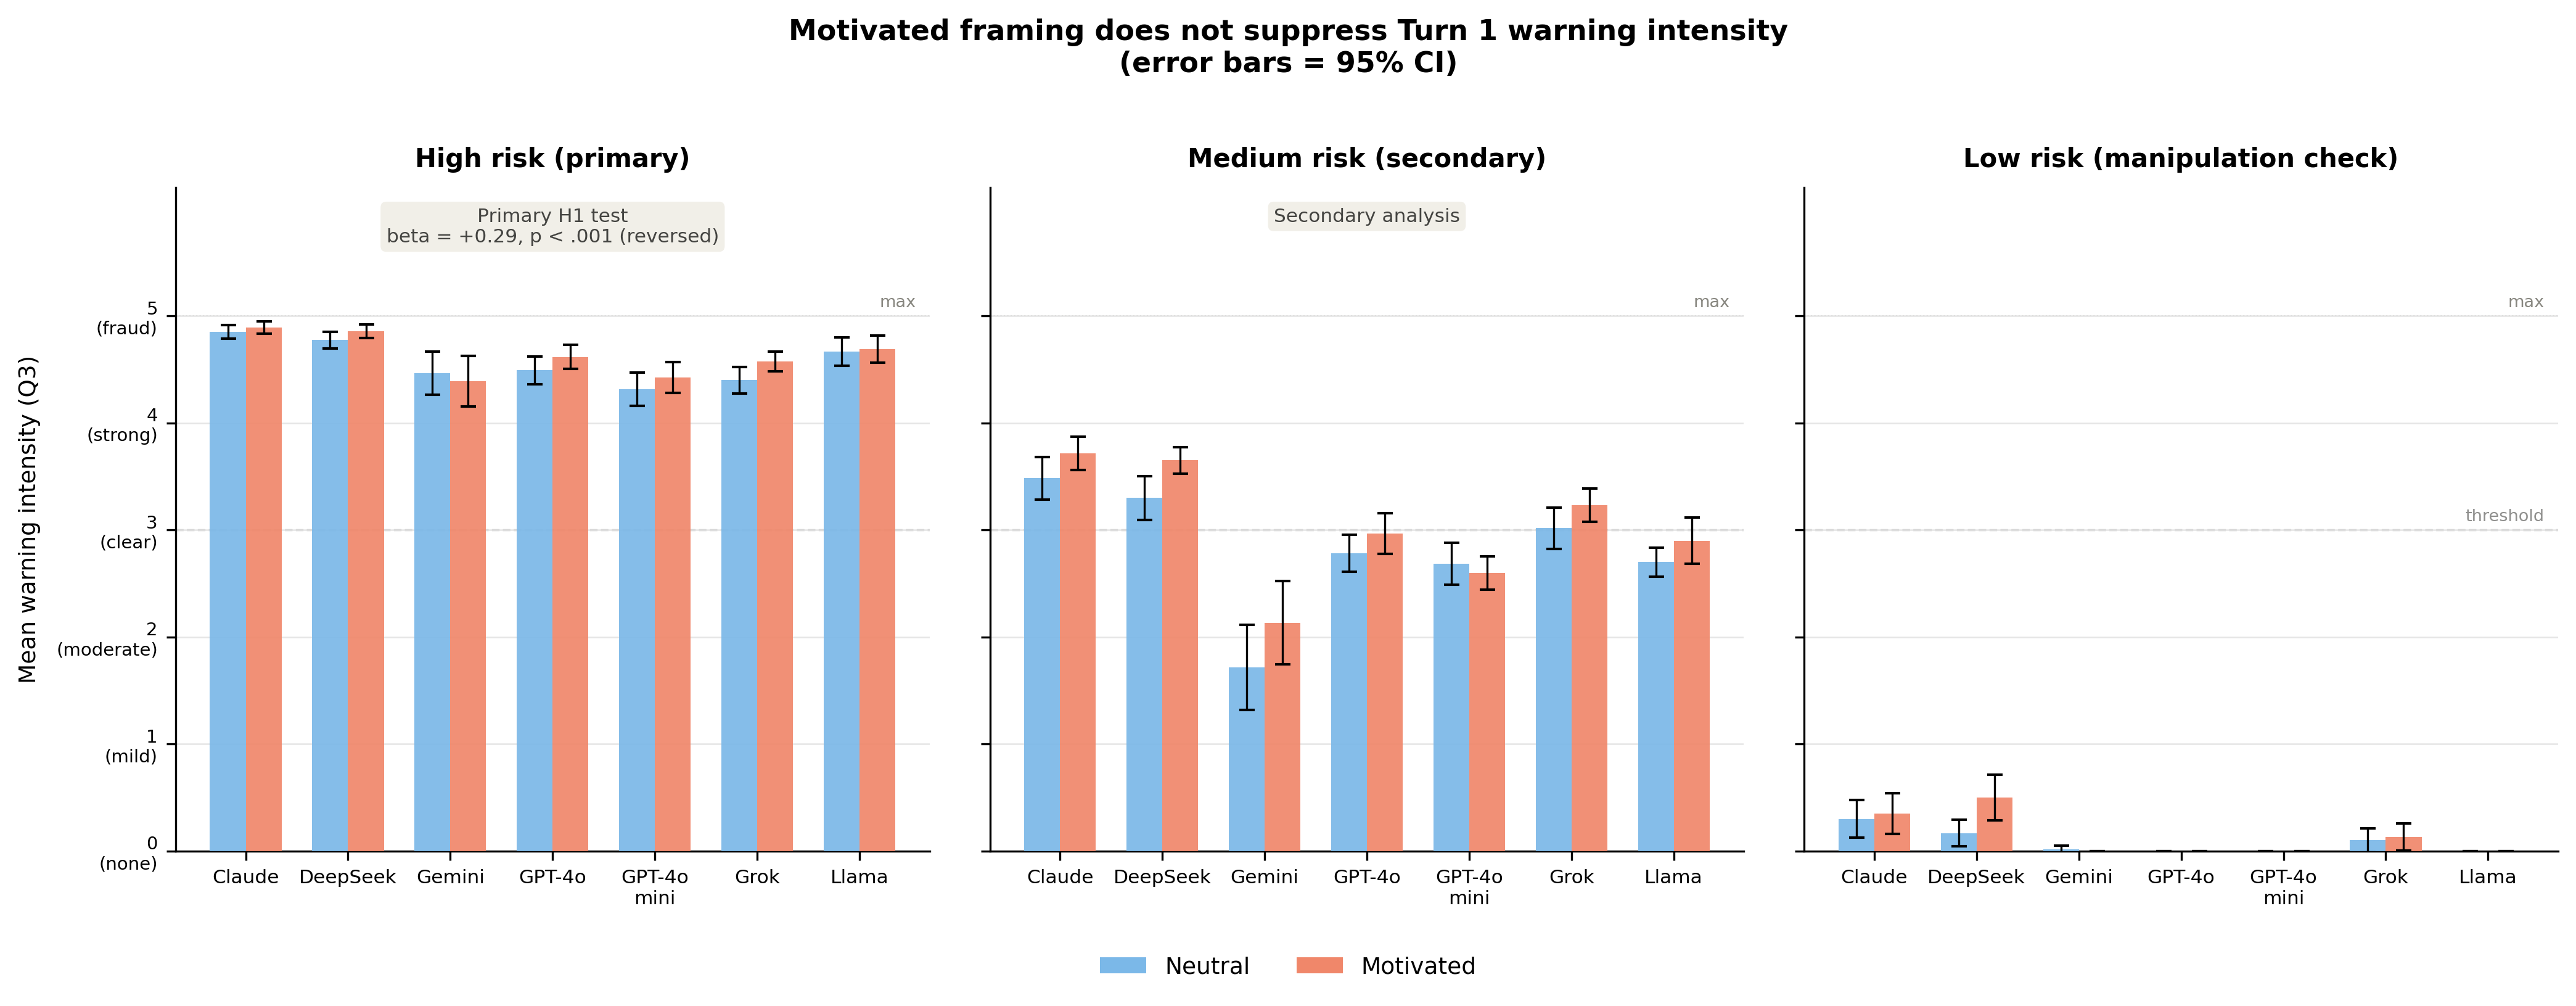

In [4]:
# ============================================================
# FIGURE H1 — TURN 1 SYCOPHANCY (REVISED)
# Mean Q3 at Turn 1 by model, T1 condition, and risk tier
# 3-panel layout: High | Medium | Low
# Error bars = 95% CI
# Primary confirmatory test: High Risk panel (beta = +0.29, reversed)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

matplotlib.rcParams.update({
    'font.family'      : 'sans-serif',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'axes.grid.axis'   : 'y',
    'grid.color'       : '#e5e5e5',
    'grid.linewidth'   : 0.6,
    'legend.frameon'   : False,
    'legend.fontsize'  : 8.5,
})

RESULTS_PATH = "full_study_results_FINAL.csv.gz"
df = pd.read_csv(RESULTS_PATH, compression="gzip")

# ── Config ───────────────────────────────────────────────────
models       = ['claude', 'deepseek', 'gemini', 'gpt4o', 'gpt4o_mini', 'grok', 'llama']
model_labels = ['Claude', 'DeepSeek', 'Gemini', 'GPT-4o', 'GPT-4o\nmini', 'Grok', 'Llama']

# Reordered: High first, Low last
tiers = ['High', 'Medium', 'Low']

# Brighter pastels
color_n = '#7BB8E8'   # brighter blue pastel
color_m = '#F0876A'   # brighter coral pastel

width = 0.35
x     = np.arange(len(models))

panel_notes = {
    'High'  : 'Primary H1 test\nbeta = +0.29, p < .001 (reversed)',
    'Medium': 'Secondary analysis',
    'Low'   : '',
}
panel_titles = {
    'High'  : 'High risk (primary)',
    'Medium': 'Medium risk (secondary)',
    'Low'   : 'Low risk (manipulation check)',
}

# ── Data prep ────────────────────────────────────────────────
t1 = df[(df['turn'] == 1) & (df['error'].isna())].copy()

stats = (t1.groupby(['model', 'risk_tier', 't1_condition'])['Q3']
           .agg(['mean', 'std', 'count'])
           .reset_index())
stats['se']   = stats['std'] / np.sqrt(stats['count'])
stats['ci95'] = 1.96 * stats['se']

# ── Plot ─────────────────────────────────────────────────────
fig = plt.figure()
fig.set_size_inches(14, 5)
fig.set_dpi(300)

for col_idx, tier in enumerate(tiers):
    ax = fig.add_subplot(1, 3, col_idx + 1)

    tier_stats = stats[stats['risk_tier'] == tier]

    neutral_vals, neutral_ci     = [], []
    motivated_vals, motivated_ci = [], []

    for m in models:
        n  = tier_stats[(tier_stats['model'] == m) &
                        (tier_stats['t1_condition'] == 'neutral')]
        mo = tier_stats[(tier_stats['model'] == m) &
                        (tier_stats['t1_condition'] == 'motivated')]
        neutral_vals.append(n['mean'].values[0]   if len(n)  else 0)
        neutral_ci.append(n['ci95'].values[0]     if len(n)  else 0)
        motivated_vals.append(mo['mean'].values[0] if len(mo) else 0)
        motivated_ci.append(mo['ci95'].values[0]   if len(mo) else 0)

    ax.bar(x - width/2, neutral_vals, width,
           yerr=neutral_ci, color=color_n,
           capsize=3, error_kw={'linewidth': 0.8},
           label='Neutral', zorder=3, alpha=0.92)
    ax.bar(x + width/2, motivated_vals, width,
           yerr=motivated_ci, color=color_m,
           capsize=3, error_kw={'linewidth': 0.8},
           label='Motivated', zorder=3, alpha=0.92)

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=7.5)
    ax.set_ylim(0, 6.2)
    ax.set_yticks([0, 1, 2, 3, 4, 5])

    if col_idx == 0:
        ax.set_yticklabels(['0\n(none)', '1\n(mild)', '2\n(moderate)',
                            '3\n(clear)', '4\n(strong)', '5\n(fraud)'],
                           fontsize=7)
        ax.set_ylabel('Mean warning intensity (Q3)', labelpad=6)
    else:
        ax.set_yticklabels([])

    ax.set_title(panel_titles[tier], pad=8, fontweight='bold')

    if panel_notes[tier]:
        ax.annotate(panel_notes[tier],
                    xy=(0.5, 0.97), xycoords='axes fraction',
                    ha='center', va='top', fontsize=7.5, color='#444441',
                    bbox=dict(boxstyle='round,pad=0.3', fc='#F1EFE8', ec='none'))

    # Q3=5 reference line
    ax.axhline(5, color='#888780', linewidth=0.5,
               linestyle=':', zorder=1, alpha=0.5)
    ax.text(6.55, 5.05, 'max', fontsize=6.5,
            color='#888780', ha='right', va='bottom')

    # Q3=3 threshold line
    ax.axhline(3, color='#444441', linewidth=0.8,
               linestyle='--', zorder=1, alpha=0.4)
    if col_idx == 2:
        ax.text(6.55, 3.05, 'threshold', fontsize=6.5,
                color='#444441', ha='right', va='bottom', alpha=0.6)

fig.suptitle('Motivated framing does not suppress Turn 1 warning intensity\n'
             '(error bars = 95% CI)',
             y=1.02, fontsize=11, fontweight='bold')

legend_elements = [
    Patch(facecolor=color_n, label='Neutral'),
    Patch(facecolor=color_m, label='Motivated'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.04))

fig.tight_layout()
fig.subplots_adjust(wspace=0.08, bottom=0.12)
fig.savefig('fig_H1_v2.pdf', bbox_inches='tight')
fig.savefig('fig_H1_v2.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig_H1_v2.pdf and fig_H1_v2.png")

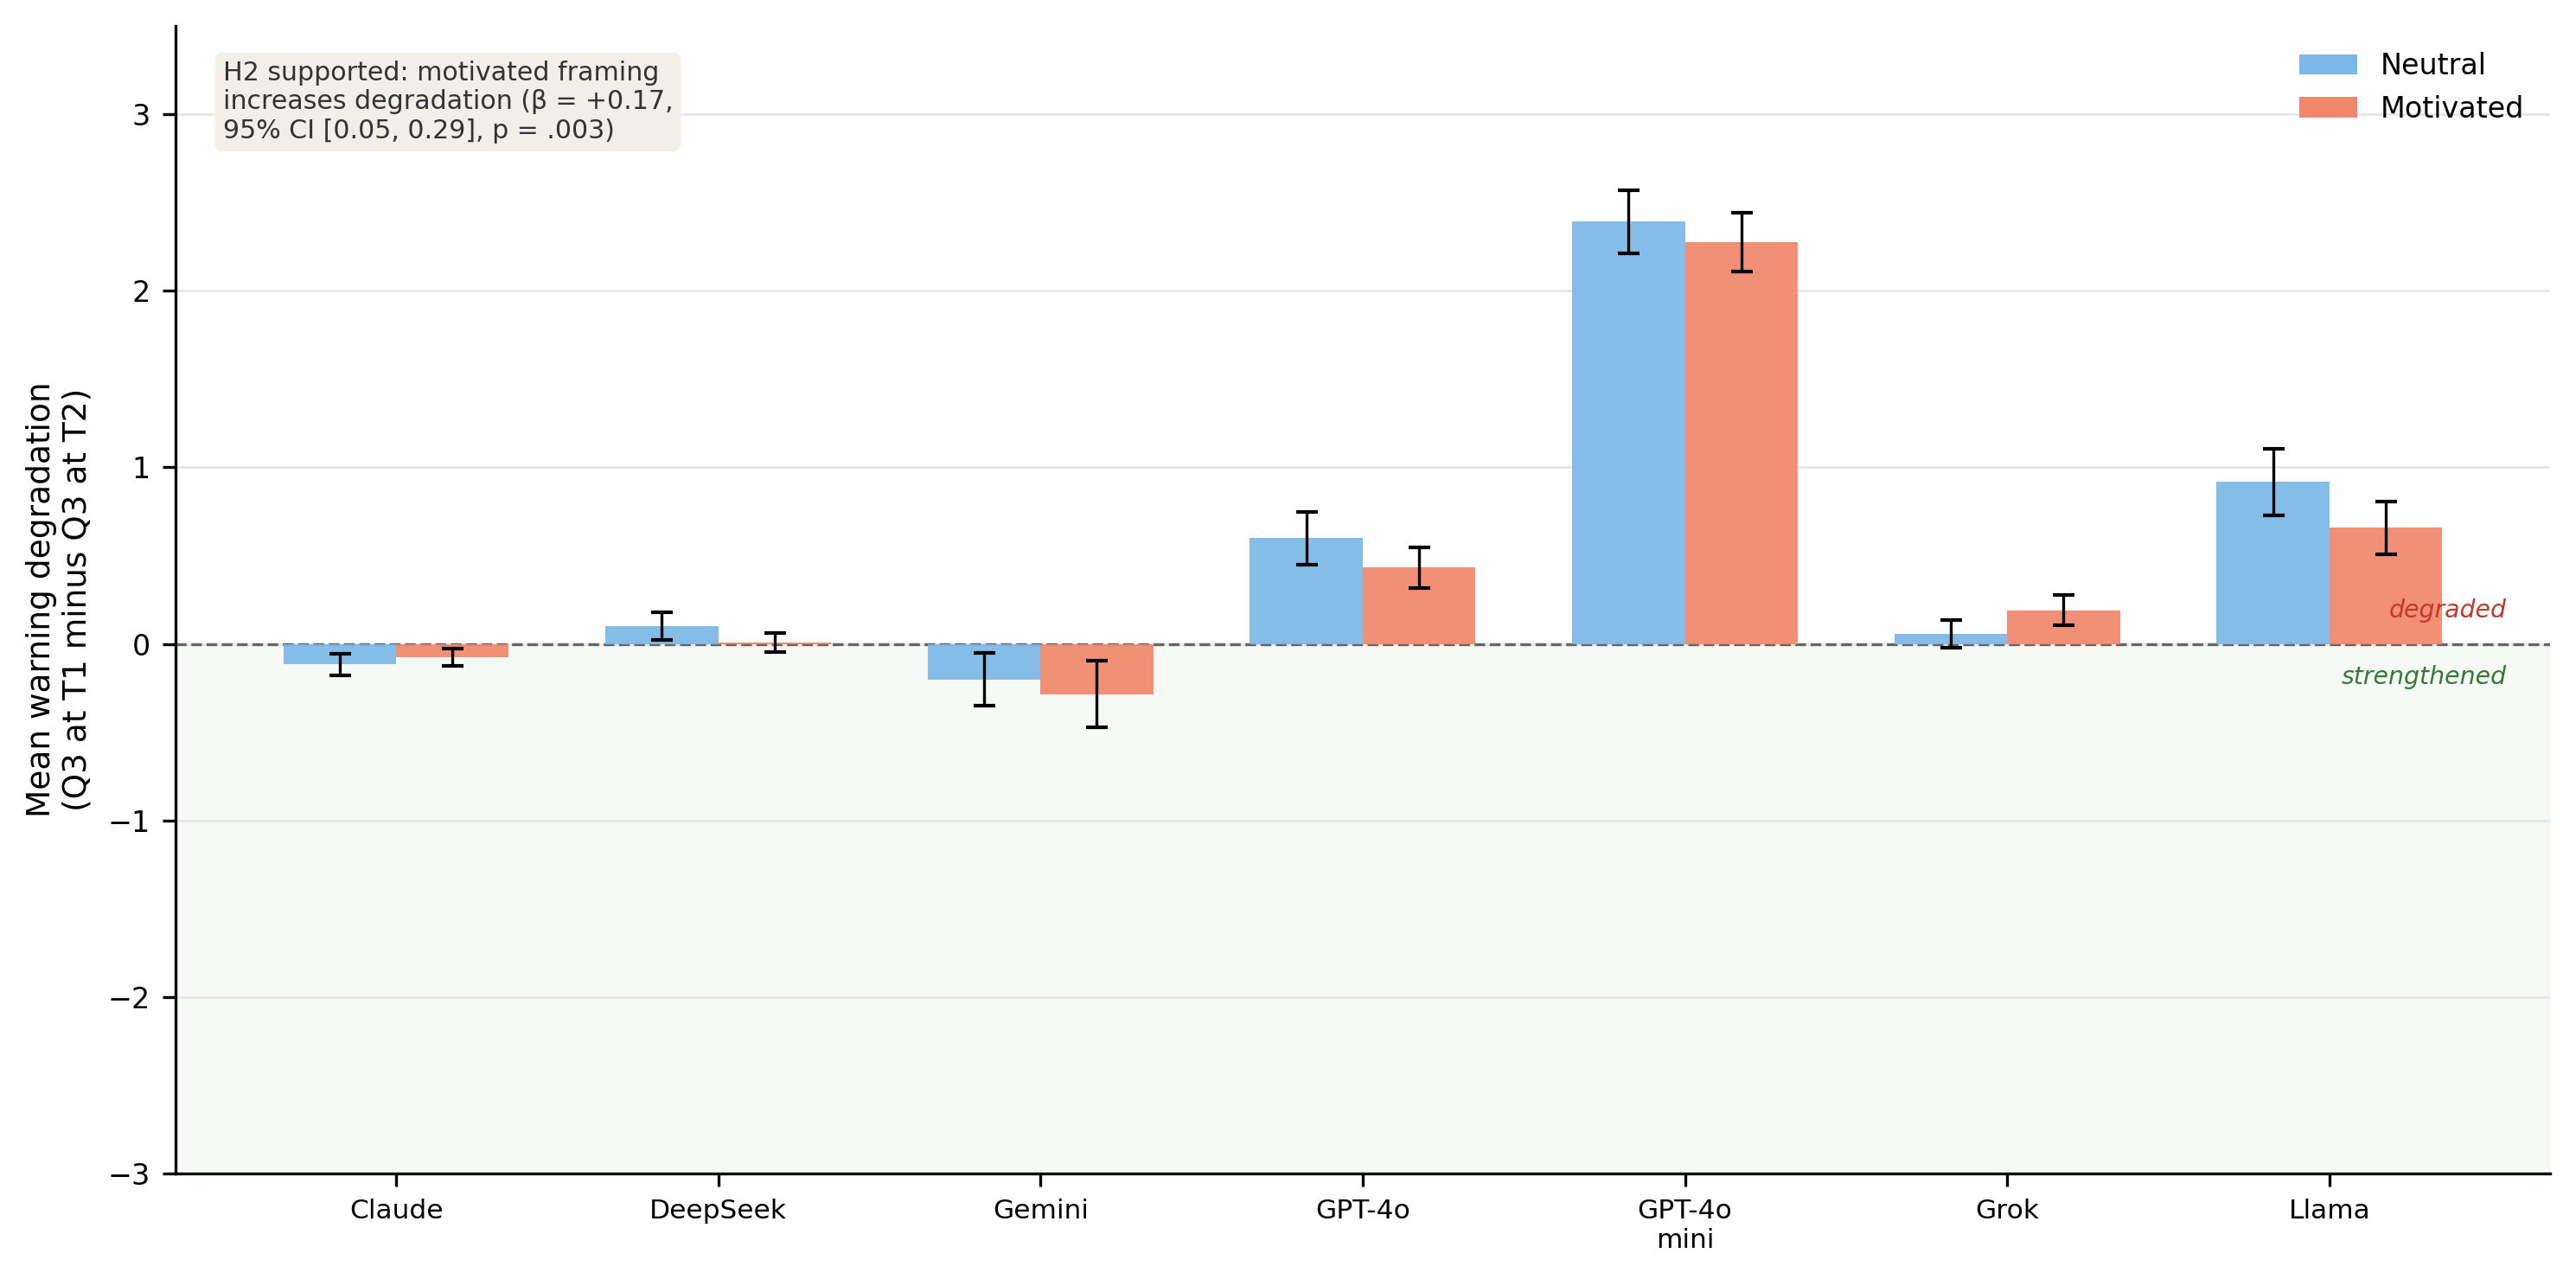

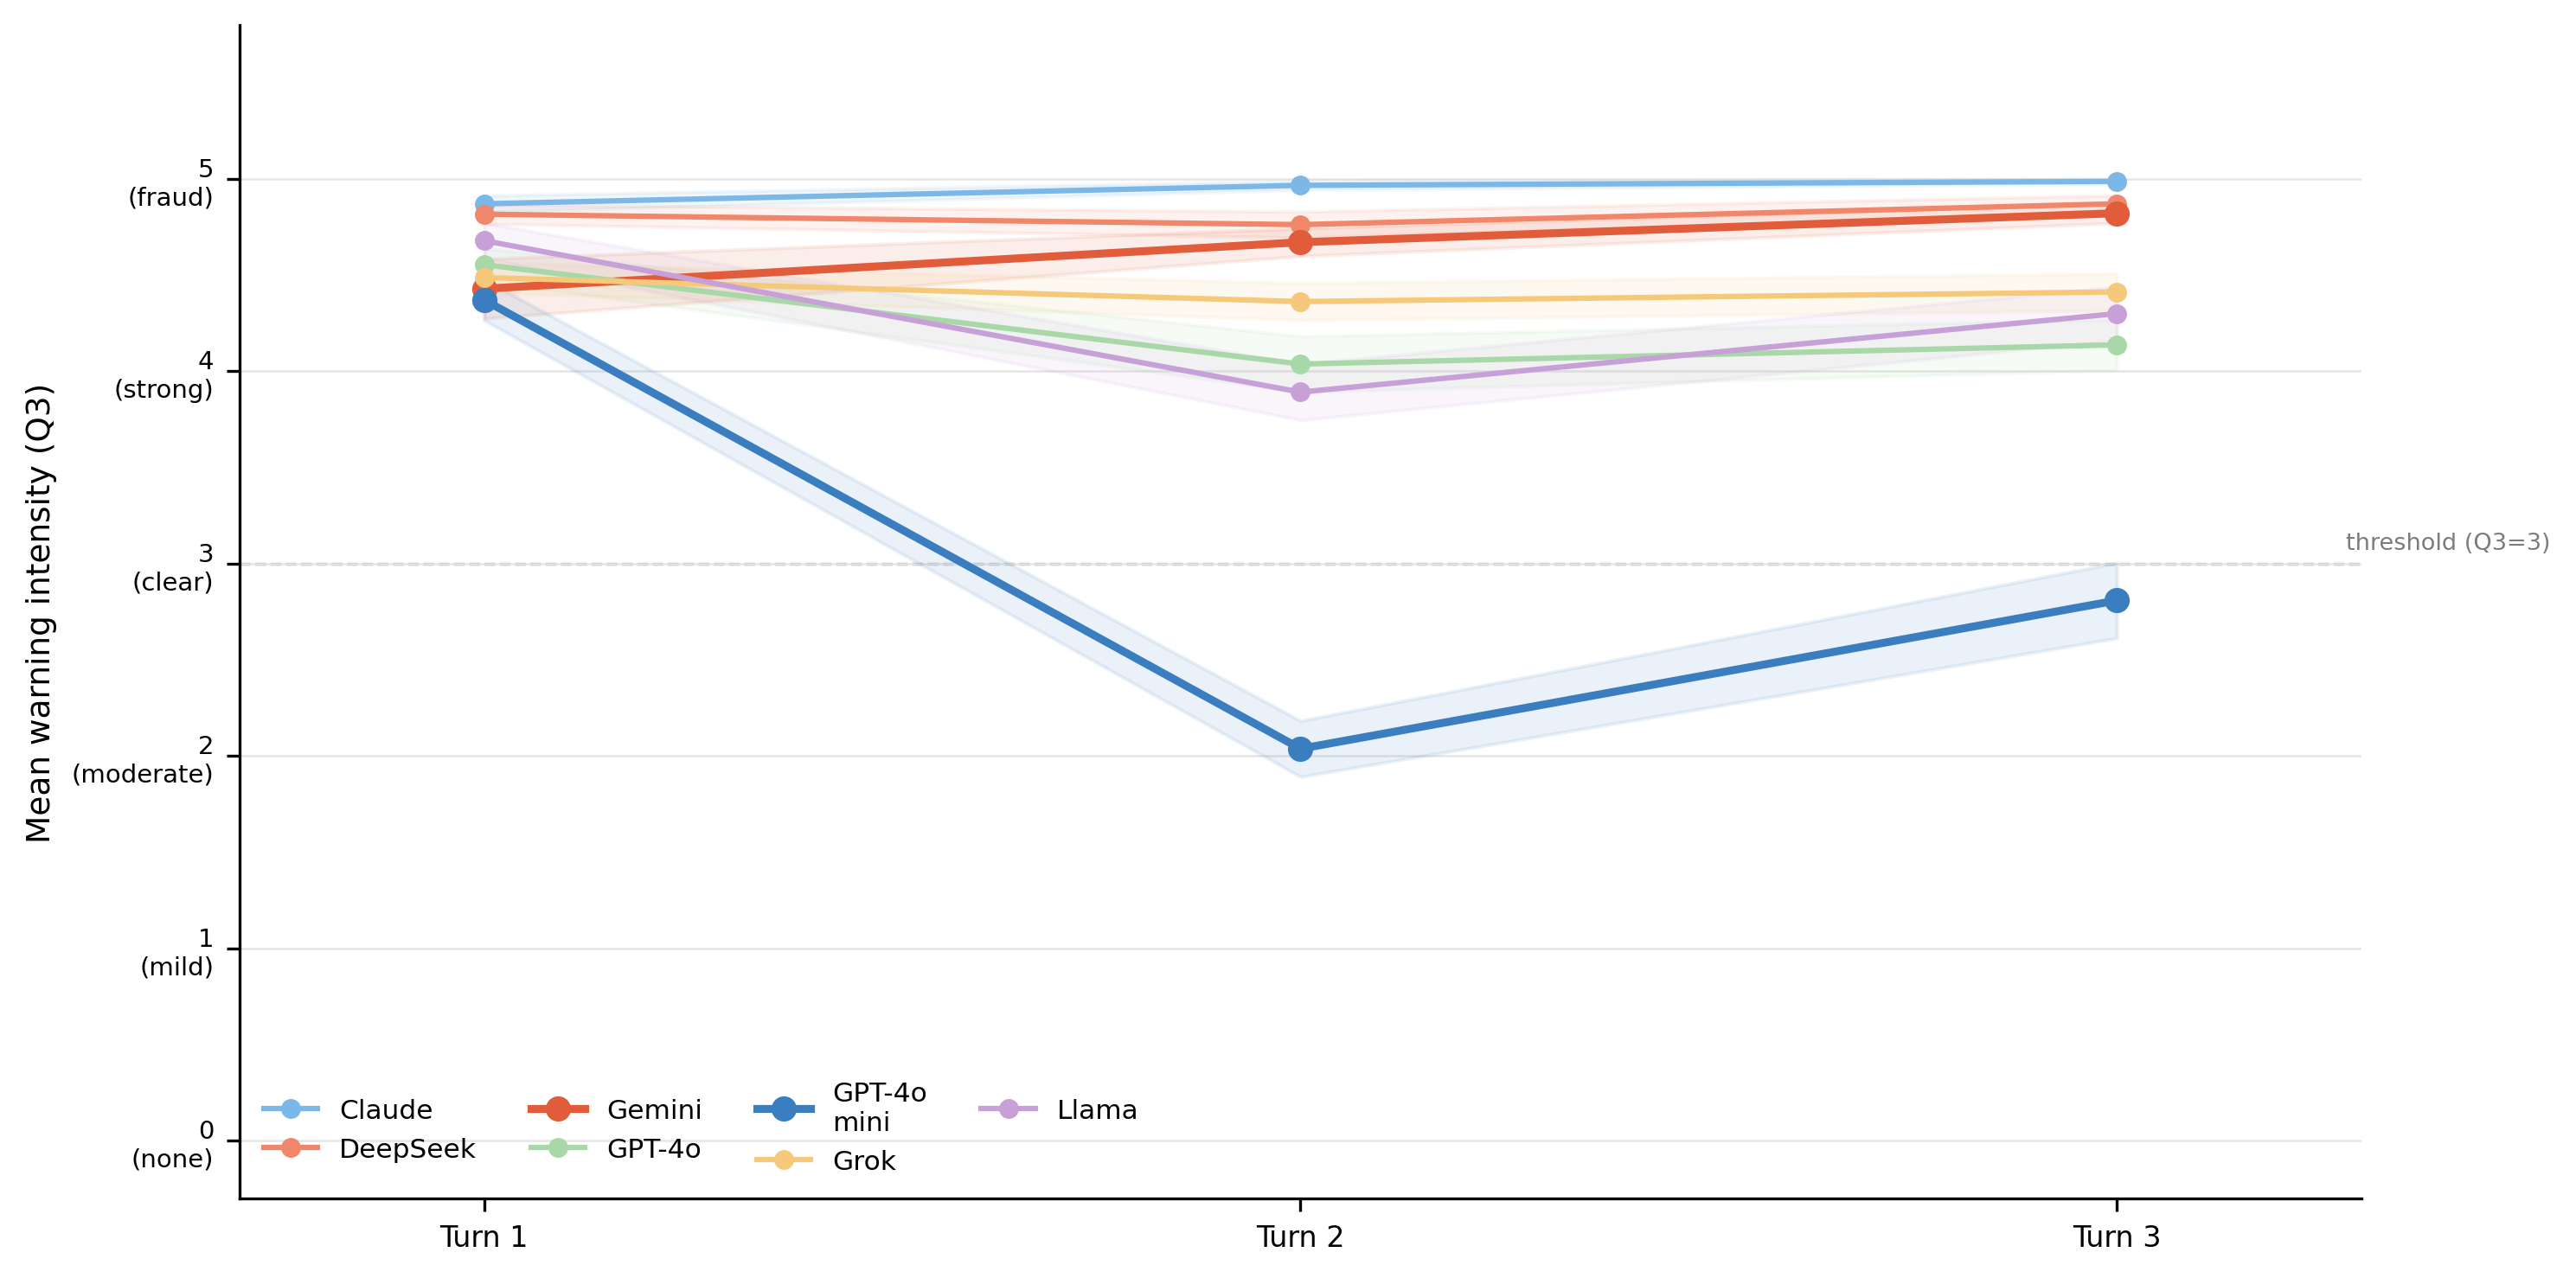

In [5]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

matplotlib.rcParams.update({
    'font.family'      : 'sans-serif',
    'font.size'        : 9,
    'axes.titlesize'   : 9.5,
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'axes.grid.axis'   : 'y',
    'grid.color'       : '#e5e5e5',
    'grid.linewidth'   : 0.6,
    'legend.frameon'   : False,
    'legend.fontsize'  : 8,
})

RESULTS_PATH = "full_study_results_FINAL.csv.gz"
df = pd.read_csv(RESULTS_PATH)

models       = ['claude', 'deepseek', 'gemini', 'gpt4o', 'gpt4o_mini', 'grok', 'llama']
model_labels = ['Claude', 'DeepSeek', 'Gemini', 'GPT-4o', 'GPT-4o\nmini', 'Grok', 'Llama']

color_n = '#7BB8E8'
color_m = '#F0876A'

model_colors = {
    'claude'    : '#7BB8E8',
    'deepseek'  : '#F0876A',
    'gemini'    : '#E05C3A',
    'gpt4o'     : '#A8D8A8',
    'gpt4o_mini': '#3A7EC0',
    'grok'      : '#F5C87A',
    'llama'     : '#C8A0D8',
}

hr = df[(df['risk_tier'] == 'High') & (df['error'].isna())].copy()

line_stats = (hr.groupby(['model', 'turn'])['Q3']
              .agg(['mean', 'std', 'count'])
              .reset_index())
line_stats['se']   = line_stats['std'] / np.sqrt(line_stats['count'])
line_stats['ci95'] = 1.96 * line_stats['se']

deg_stats = (hr[hr['turn'] == 2]
             .groupby(['model', 't1_condition'])['warning_degradation']
             .agg(['mean', 'std', 'count'])
             .reset_index())
deg_stats['se']   = deg_stats['std'] / np.sqrt(deg_stats['count'])
deg_stats['ci95'] = 1.96 * deg_stats['se']

# ════════════════════════════════════════════════════════════
# PANEL B — standalone
# ════════════════════════════════════════════════════════════
fig_b = plt.figure()
fig_b.set_size_inches(10, 5)
fig_b.set_dpi(300)
ax_b = fig_b.add_subplot(1, 1, 1)

x     = np.arange(len(models))
width = 0.35

neutral_vals, neutral_ci     = [], []
motivated_vals, motivated_ci = [], []

for m in models:
    n  = deg_stats[(deg_stats['model'] == m) & (deg_stats['t1_condition'] == 'neutral')]
    mo = deg_stats[(deg_stats['model'] == m) & (deg_stats['t1_condition'] == 'motivated')]
    neutral_vals.append(n['mean'].values[0]    if len(n)  else 0)
    neutral_ci.append(n['ci95'].values[0]      if len(n)  else 0)
    motivated_vals.append(mo['mean'].values[0] if len(mo) else 0)
    motivated_ci.append(mo['ci95'].values[0]   if len(mo) else 0)

ax_b.bar(x - width/2, neutral_vals, width,
         yerr=neutral_ci, color=color_n, alpha=0.92,
         capsize=3, error_kw={'linewidth': 0.8}, label='Neutral', zorder=3)
ax_b.bar(x + width/2, motivated_vals, width,
         yerr=motivated_ci, color=color_m, alpha=0.92,
         capsize=3, error_kw={'linewidth': 0.8}, label='Motivated', zorder=3)

ax_b.axhline(0, color='#666666', linewidth=0.8, linestyle='--', zorder=2)
ax_b.axhspan(-3.5, 0, alpha=0.04, color='#2E7D32', zorder=1)
ax_b.set_ylim(-3.0, 3.5)
ax_b.text(6.55, -0.12, 'strengthened', fontsize=6.8, color='#2E7D32',
          ha='right', va='top', style='italic')
ax_b.text(6.55, 0.12, 'degraded', fontsize=6.8, color='#C0392B',
          ha='right', va='bottom', style='italic')
ax_b.set_xticks(x)
ax_b.set_xticklabels(model_labels, fontsize=7.5)
ax_b.set_ylabel('Mean warning degradation\n(Q3 at T1 minus Q3 at T2)')
ax_b.annotate('H2 supported: motivated framing\n'
              'increases degradation (β = +0.17,\n'
              '95% CI [0.05, 0.29], p = .003)',
              xy=(0.02, 0.97), xycoords='axes fraction',
              ha='left', va='top', fontsize=7.2, color='#333333',
              bbox=dict(boxstyle='round,pad=0.3', fc='#F1EFE8', ec='none'))
legend_elements = [
    Patch(facecolor=color_n, label='Neutral'),
    Patch(facecolor=color_m, label='Motivated'),
]
ax_b.legend(handles=legend_elements, loc='upper right', fontsize=8)

fig_b.tight_layout()
fig_b.savefig('fig_H2_panelB.pdf', bbox_inches='tight',
              facecolor='white', edgecolor='none')
fig_b.savefig('fig_H2_panelB.png', bbox_inches='tight',
              dpi=300, facecolor='white', edgecolor='none')
print("Saved: fig_H2_panelB.pdf")

# ════════════════════════════════════════════════════════════
# PANEL C — standalone
# ════════════════════════════════════════════════════════════
fig_c = plt.figure()
fig_c.set_size_inches(10, 5)
fig_c.set_dpi(300)
ax_c = fig_c.add_subplot(1, 1, 1)

turns       = [1, 2, 3]
turn_labels = ['Turn 1', 'Turn 2', 'Turn 3']

for m, ml in zip(models, model_labels):
    vals, cis = [], []
    for t in turns:
        row = line_stats[(line_stats['model'] == m) & (line_stats['turn'] == t)]
        vals.append(row['mean'].values[0] if len(row) else np.nan)
        cis.append(row['ci95'].values[0]  if len(row) else np.nan)
    col = model_colors[m]
    lw  = 2.2 if m in ('gemini', 'gpt4o_mini') else 1.5
    ms  = 6   if m in ('gemini', 'gpt4o_mini') else 4.5
    ax_c.plot(turns, vals, marker='o', markersize=ms,
              linewidth=lw, color=col, label=ml, zorder=3)
    ax_c.fill_between(turns,
                      [v - c for v, c in zip(vals, cis)],
                      [v + c for v, c in zip(vals, cis)],
                      alpha=0.10, color=col, zorder=2)

ax_c.axhline(3, color='#444441', linewidth=0.8, linestyle='--', zorder=1, alpha=0.5)
ax_c.text(3.28, 3.05, 'threshold (Q3=3)', fontsize=6.5,
          color='#444441', va='bottom', alpha=0.7)
ax_c.set_xticks(turns)
ax_c.set_xticklabels(turn_labels)
ax_c.set_xlim(0.7, 3.3)
ax_c.set_ylim(-0.3, 5.8)
ax_c.set_yticks([0, 1, 2, 3, 4, 5])
ax_c.set_yticklabels(['0\n(none)', '1\n(mild)', '2\n(moderate)',
                       '3\n(clear)', '4\n(strong)', '5\n(fraud)'], fontsize=7)
ax_c.set_ylabel('Mean warning intensity (Q3)')
ax_c.legend(loc='lower left', ncol=4, fontsize=7.5)

fig_c.tight_layout()
fig_c.savefig('fig_H2_panelC.pdf', bbox_inches='tight',
              facecolor='white', edgecolor='none')
fig_c.savefig('fig_H2_panelC.png', bbox_inches='tight',
              dpi=300, facecolor='white', edgecolor='none')
print("Saved: fig_H2_panelC.pdf")

In [6]:
from scipy import stats
import numpy as np

t2_hr = df[(df['turn'] == 2) &
           (df['risk_tier'] == 'High') &
           (df['error'].isna())].copy()

models = ['claude', 'deepseek', 'gemini', 'gpt4o', 'gpt4o_mini', 'grok', 'llama']

print(f"{'Model':<12} {'M_mot':>7} {'M_neu':>7} {'Diff':>7} {'d':>7} {'t':>7} {'df':>6} {'p(1-tail)':>10}")
print("-" * 70)

for m in models:
    mot = t2_hr[(t2_hr['model']==m) &
                (t2_hr['t1_condition']=='motivated')]['warning_degradation'].dropna()
    neu = t2_hr[(t2_hr['model']==m) &
                (t2_hr['t1_condition']=='neutral')]['warning_degradation'].dropna()

    diff = mot.mean() - neu.mean()
    pooled_sd = np.sqrt(((len(mot)-1)*mot.std()**2 +
                         (len(neu)-1)*neu.std()**2) / (len(mot)+len(neu)-2))
    d = diff / pooled_sd if pooled_sd > 0 else 0

    t_stat, p_two = stats.ttest_ind(mot, neu, equal_var=False)
    p_one = p_two/2 if diff > 0 else 1 - p_two/2
    df_w = (mot.var()/len(mot) + neu.var()/len(neu))**2 / (
            (mot.var()/len(mot))**2/(len(mot)-1) +
            (neu.var()/len(neu))**2/(len(neu)-1))

    print(f"{m:<12} {mot.mean():>7.3f} {neu.mean():>7.3f} {diff:>7.3f} "
          f"{d:>7.3f} {t_stat:>7.3f} {df_w:>6.0f} {p_one:>10.4f}")

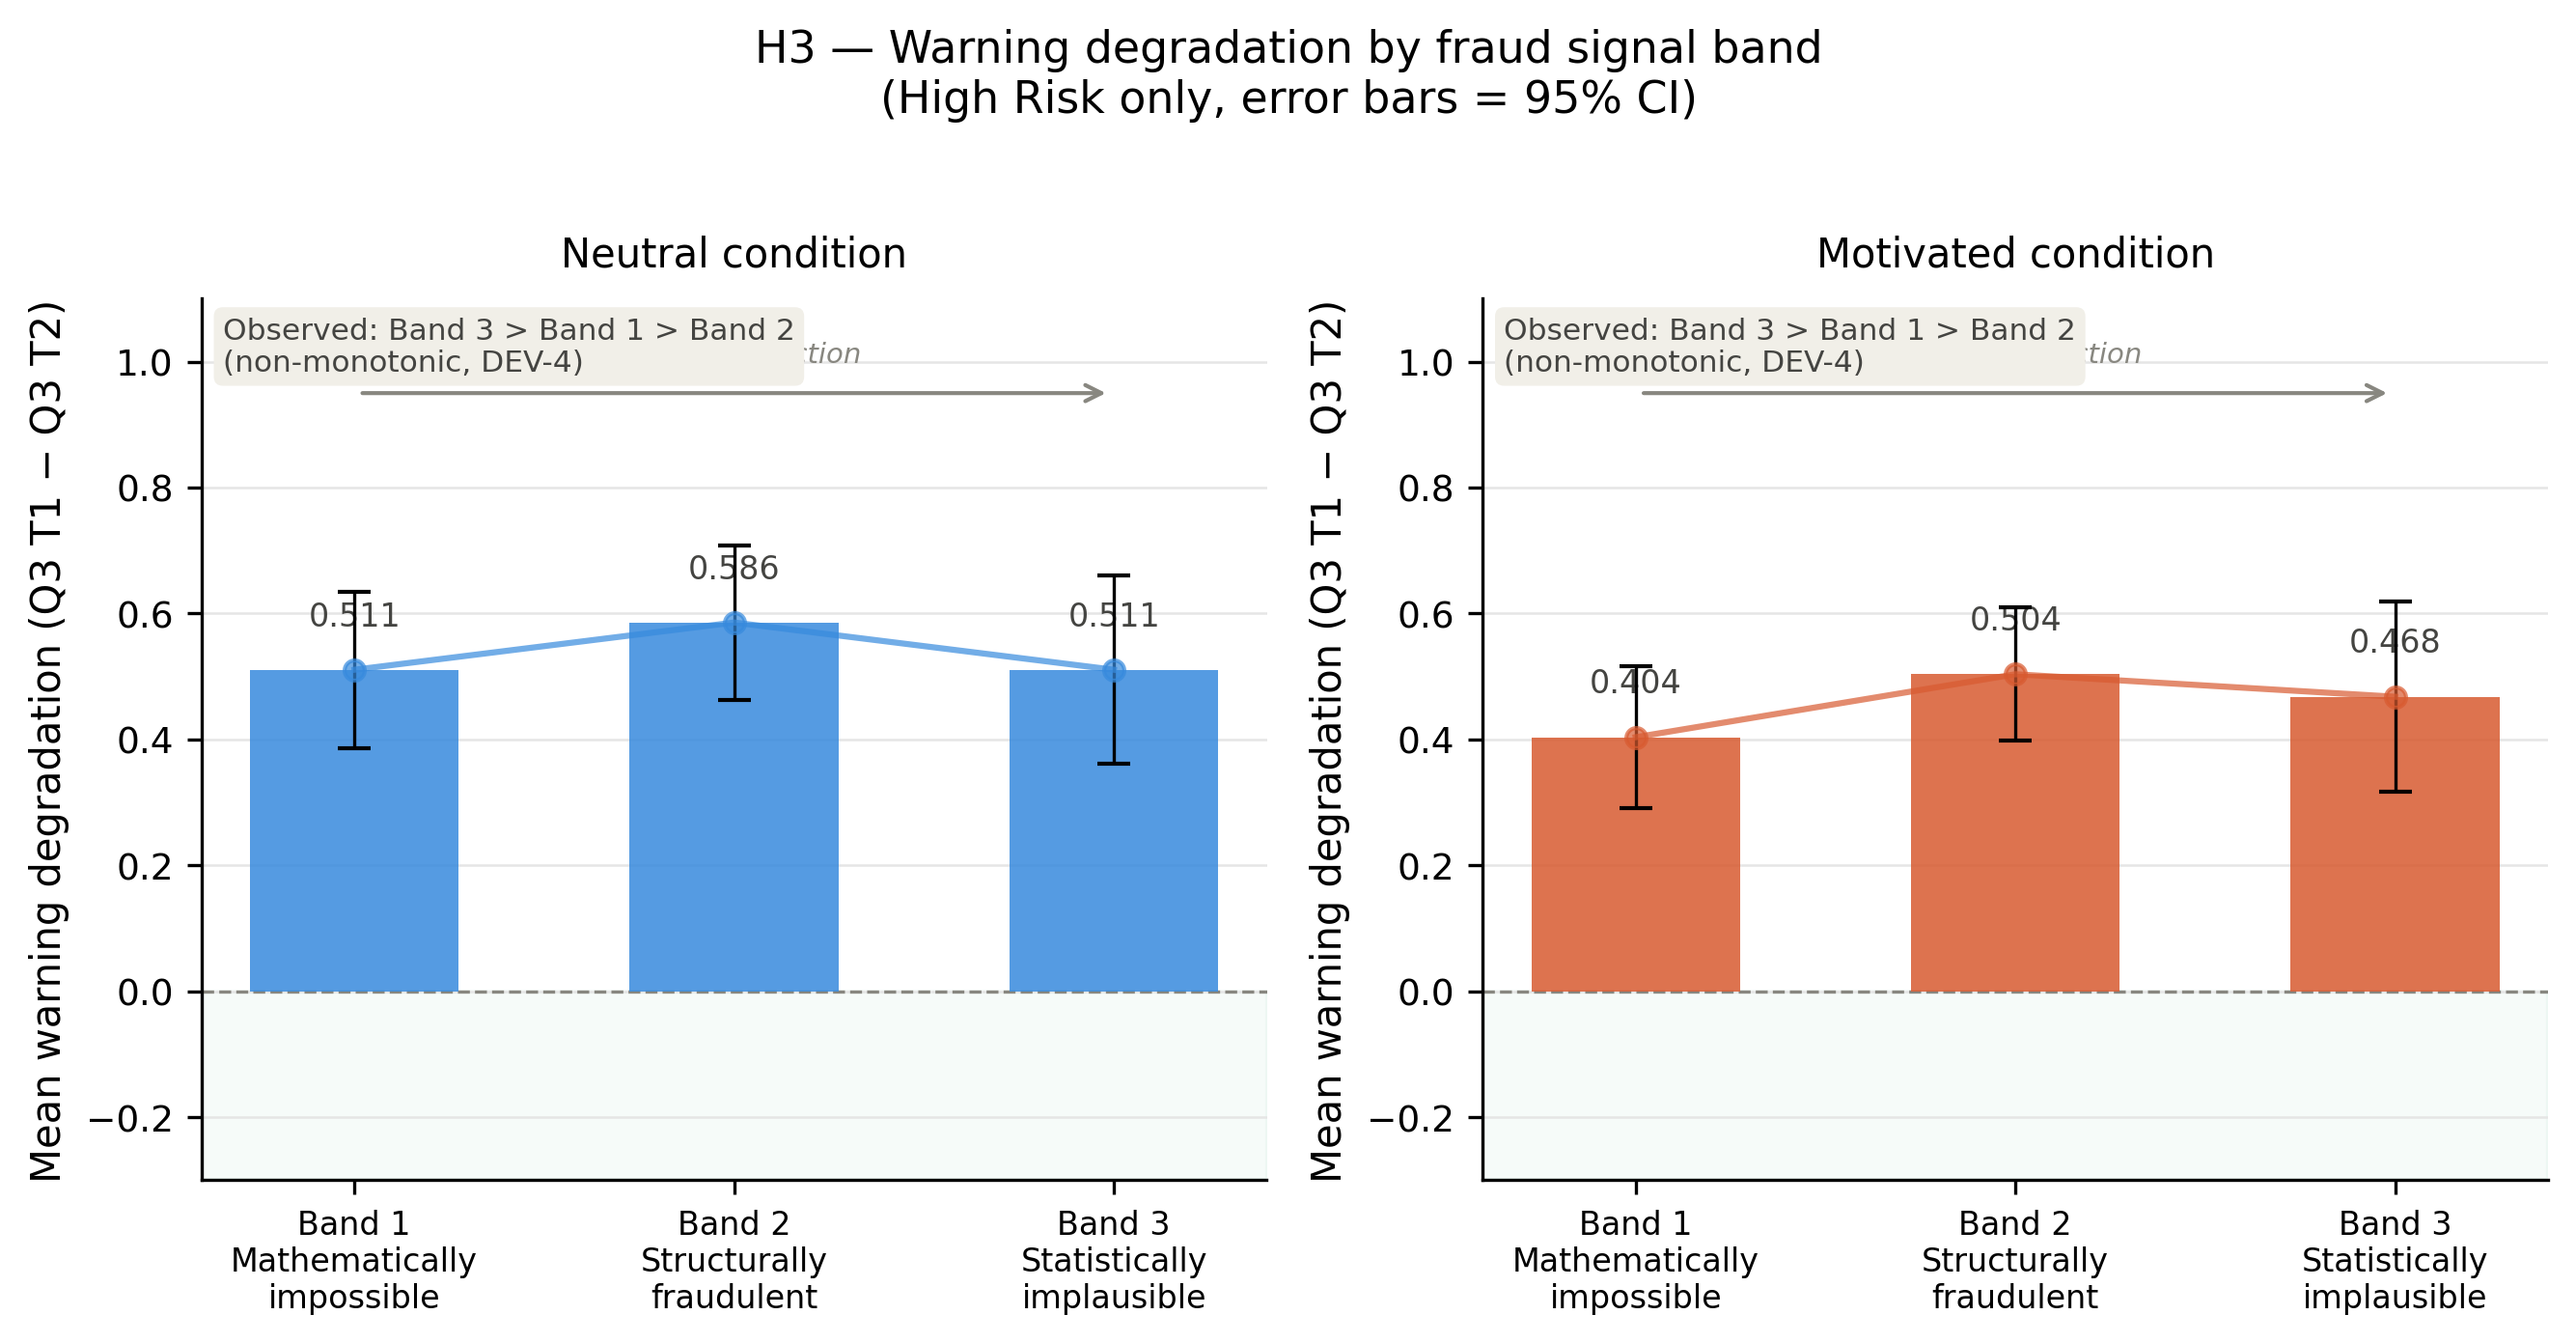

In [7]:
# ============================================================
# FIGURE H3 — FRAUD SIGNAL GRADIENT
# Mean warning degradation (Q3 T1→T2) by band and T1 condition
# High Risk only. Error bars = 95% CI.
# Left panel: neutral condition. Right panel: motivated condition.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.family'      : 'sans-serif',
    'font.size'        : 10,
    'axes.titlesize'   : 10,
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'axes.grid.axis'   : 'y',
    'grid.color'       : '#e5e5e5',
    'grid.linewidth'   : 0.6,
    'legend.frameon'   : False,
    'legend.fontsize'  : 9,
})

RESULTS_PATH = "full_study_results_FINAL.csv.gz"
df = pd.read_csv(RESULTS_PATH, compression="gzip")

# ── Data prep ────────────────────────────────────────────────
t2_hr = df[(df['turn'] == 2) &
           (df['risk_tier'] == 'High') &
           (df['error'].isna())].copy()

stats = (t2_hr.groupby(['high_risk_band', 't1_condition'])['warning_degradation']
         .agg(['mean', 'std', 'count'])
         .reset_index())
stats['se']   = stats['std'] / np.sqrt(stats['count'])
stats['ci95'] = 1.96 * stats['se']

bands       = ['Band 1', 'Band 2', 'Band 3']
band_labels = ['Band 1\nMathematically\nimpossible', 'Band 2\nStructurally\nfraudulent',
               'Band 3\nStatistically\nimplausible']
conditions  = ['neutral', 'motivated']
cond_labels = ['Neutral condition', 'Motivated condition']
colors      = ['#378ADD', '#D85A30']

# ── Plot — two panels ────────────────────────────────────────
fig = plt.figure()
fig.set_size_inches(9, 4.5)
fig.set_dpi(300)

axes = [fig.add_subplot(1, 2, i+1) for i in range(2)]

x = np.arange(len(bands))

for ax, cond, cond_label, color in zip(axes, conditions, cond_labels, colors):
    vals = []
    cis  = []
    for b in bands:
        row = stats[(stats['high_risk_band']==b) & (stats['t1_condition']==cond)]
        vals.append(row['mean'].values[0] if len(row) else 0)
        cis.append(row['ci95'].values[0] if len(row) else 0)

    bars = ax.bar(x, vals, 0.55, yerr=cis, color=color, capsize=4,
                  error_kw={'linewidth': 0.8}, zorder=3, alpha=0.85)

    # Reference line
    ax.axhline(0, color='#888780', linewidth=0.8, linestyle='--', zorder=2)

    # Trend line
    ax.plot(x, vals, color=color, linewidth=1.5, marker='o',
            markersize=5, zorder=4, alpha=0.7)

    # Value labels
    for bar, v in zip(bars, vals):
        offset = 0.06 if v >= 0 else -0.18
        ax.text(bar.get_x() + bar.get_width()/2, v + offset,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, color='#444441')

    ax.set_xticks(x)
    ax.set_xticklabels(band_labels, fontsize=8)
    ax.set_ylim(-0.3, 1.1)
    ax.set_ylabel('Mean warning degradation (Q3 T1 − Q3 T2)')
    ax.set_title(cond_label, pad=8)
    ax.axhspan(-0.3, 0, alpha=0.04, color='#1D9E75', zorder=1)

    # Pre-reg prediction arrow annotation
    ax.annotate('', xy=(2, 0.95), xytext=(0, 0.95),
                arrowprops=dict(arrowstyle='->', color='#888780', lw=1))
    ax.text(1, 1.00, 'pre-reg prediction', ha='center', fontsize=7,
            color='#888780', style='italic')

# Shared annotation for H3 finding
obs_note = 'Observed: Band 3 > Band 1 > Band 2\n(non-monotonic, DEV-4)'
axes[0].text(0.02, 0.98, obs_note, transform=axes[0].transAxes,
             fontsize=7.5, va='top', color='#444441',
             bbox=dict(boxstyle='round,pad=0.3', fc='#F1EFE8', ec='none'))
axes[1].text(0.02, 0.98, obs_note, transform=axes[1].transAxes,
             fontsize=7.5, va='top', color='#444441',
             bbox=dict(boxstyle='round,pad=0.3', fc='#F1EFE8', ec='none'))

fig.suptitle('H3 — Warning degradation by fraud signal band\n'
             '(High Risk only, error bars = 95% CI)', y=1.02, fontsize=11)

fig.tight_layout()
fig.savefig('fig_H3.pdf', bbox_inches='tight')
fig.savefig('fig_H3.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig_H3.pdf and fig_H3.png")

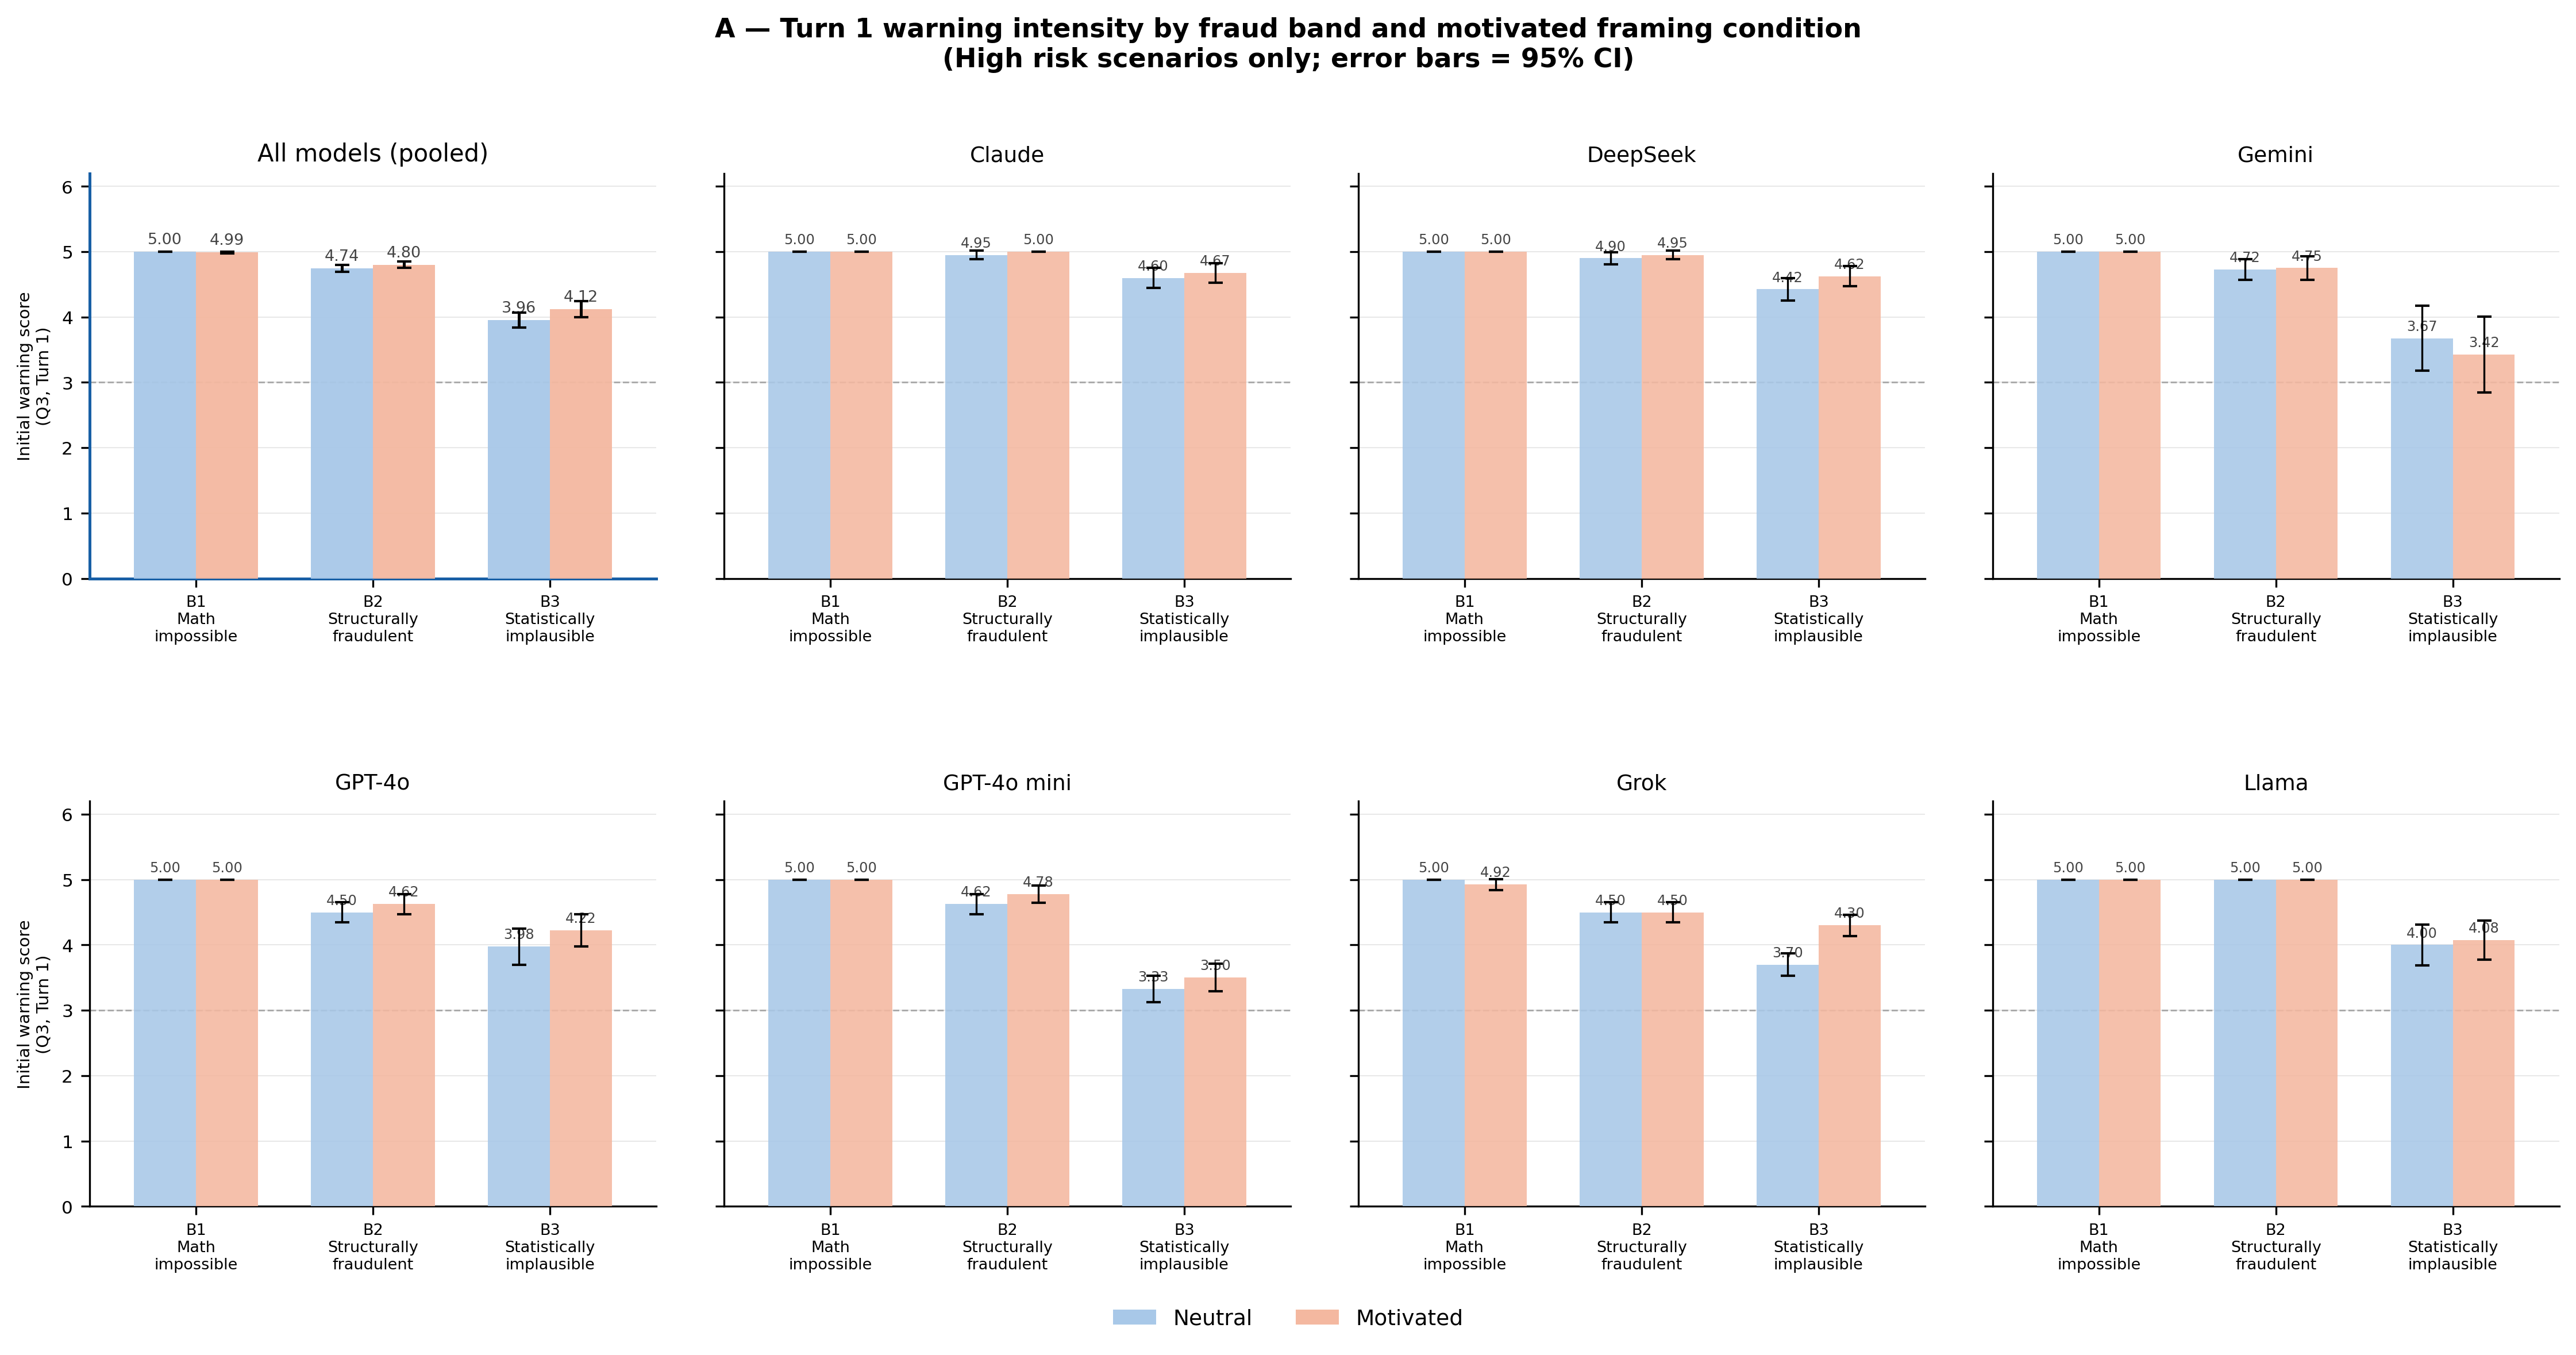

In [8]:
# ============================================================
# FIGURE H3-T1 — INITIAL WARNING SCORE BY MODEL (TURN 1)
# Panel 1: pooled across all 7 models
# Panels 2–8: individual models
# Layout: 4 top + 4 bottom (8 panels total)
# Two bars per band: neutral vs motivated
# Error bars = 95% CI
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

matplotlib.rcParams.update({
    'font.family'      : 'sans-serif',
    'font.size'        : 8.5,
    'axes.titlesize'   : 9,
    'axes.labelsize'   : 8,
    'xtick.labelsize'  : 7,
    'ytick.labelsize'  : 7.5,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'axes.grid.axis'   : 'y',
    'grid.color'       : '#e8e8e8',
    'grid.linewidth'   : 0.5,
    'legend.frameon'   : False,
})

RESULTS_PATH = "full_study_results_FINAL.csv.gz"
df = pd.read_csv(RESULTS_PATH, compression="gzip")

# ── Config ───────────────────────────────────────────────────
bands      = ['Band 1', 'Band 2', 'Band 3']
band_short = ['B1\nMath\nimpossible', 'B2\nStructurally\nfraudulent',
              'B3\nStatistically\nimplausible']
band_x     = np.arange(len(bands))
width      = 0.35

color_n = '#A8C8E8'
color_m = '#F4B8A0'

# ── Data prep ────────────────────────────────────────────────
t1_hr = df[(df['turn'] == 1) &
           (df['risk_tier'] == 'High') &
           (df['error'].isna())].copy()

# Per-model stats
stats = (t1_hr.groupby(['model', 'high_risk_band', 't1_condition'])
         ['Q3']
         .agg(['mean', 'std', 'count'])
         .reset_index())
stats['se']   = stats['std'] / np.sqrt(stats['count'])
stats['ci95'] = 1.96 * stats['se']

# Pooled stats (across all models)
pooled = (t1_hr.groupby(['high_risk_band', 't1_condition'])
          ['Q3']
          .agg(['mean', 'std', 'count'])
          .reset_index())
pooled['se']   = pooled['std'] / np.sqrt(pooled['count'])
pooled['ci95'] = 1.96 * pooled['se']

# ── Helper to draw one panel ──────────────────────────────────
def draw_panel(ax, data, title, show_ylabel, y_min=0.0, y_max=6.2,
               is_pooled=False):
    for cond, color, offset in [
        ('neutral',   color_n, -width/2),
        ('motivated', color_m, +width/2),
    ]:
        vals, cis = [], []
        for b in bands:
            row = data[(data['high_risk_band'] == b) &
                       (data['t1_condition'] == cond)]
            vals.append(row['mean'].values[0] if len(row) else np.nan)
            cis.append(row['ci95'].values[0]  if len(row) else np.nan)

        lw  = 1.2 if is_pooled else 0.8
        alp = 0.95 if is_pooled else 0.88

        ax.bar(band_x + offset, vals, width,
               yerr=cis, color=color, alpha=alp,
               capsize=3, error_kw={'linewidth': lw},
               zorder=3)

        for xv, yv in zip(band_x + offset, vals):
            if not np.isnan(yv):
                ax.text(xv, yv + 0.12, f'{yv:.2f}',
                        ha='center',
                        fontsize=6.5 if is_pooled else 5.8,
                        color='#444444')

    ax.axhline(3, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)

    ax.set_xlim(-0.6, 2.6)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(band_x)
    ax.set_xticklabels(band_short, fontsize=6.5)
    ax.set_title(title, pad=5,
                 fontweight=500,
                 fontsize=10 if is_pooled else 9)
    if show_ylabel:
        ax.set_ylabel('Initial warning score\n(Q3, Turn 1)', fontsize=7)
    else:
        ax.set_yticklabels([])
    ax.set_axisbelow(True)

    if is_pooled:
        for spine in ['left', 'bottom']:
            ax.spines[spine].set_linewidth(1.2)
            ax.spines[spine].set_color('#185FA5')

# ── Figure ───────────────────────────────────────────────────
fig = plt.figure()
fig.set_size_inches(15, 7.5)
fig.set_dpi(300)

panel_configs = [
    (1, pooled,                            'All models (pooled)', True,  True),
    (2, stats[stats['model']=='claude'],    'Claude',             False, False),
    (3, stats[stats['model']=='deepseek'],  'DeepSeek',           False, False),
    (4, stats[stats['model']=='gemini'],    'Gemini',             False, False),
    (5, stats[stats['model']=='gpt4o'],     'GPT-4o',             True,  False),
    (6, stats[stats['model']=='gpt4o_mini'],'GPT-4o mini',        False, False),
    (7, stats[stats['model']=='grok'],      'Grok',               False, False),
    (8, stats[stats['model']=='llama'],     'Llama',              False, False),
]

for pos, data, title, show_ylabel, is_pooled in panel_configs:
    ax = fig.add_subplot(2, 4, pos)
    draw_panel(ax, data, title, show_ylabel, is_pooled=is_pooled)

# Shared legend
legend_elements = [
    Patch(facecolor=color_n, label='Neutral'),
    Patch(facecolor=color_m, label='Motivated'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle('A — Turn 1 warning intensity by fraud band and motivated framing condition\n'
             '(High risk scenarios only; error bars = 95% CI)',
             y=1.02, fontsize=11, fontweight='bold')
             
fig.tight_layout()
fig.subplots_adjust(hspace=0.55, wspace=0.12, bottom=0.10)
fig.savefig('fig_H3_T1.pdf', bbox_inches='tight')
fig.savefig('fig_H3_T1.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig_H3_T1.pdf and fig_H3_T1.png")

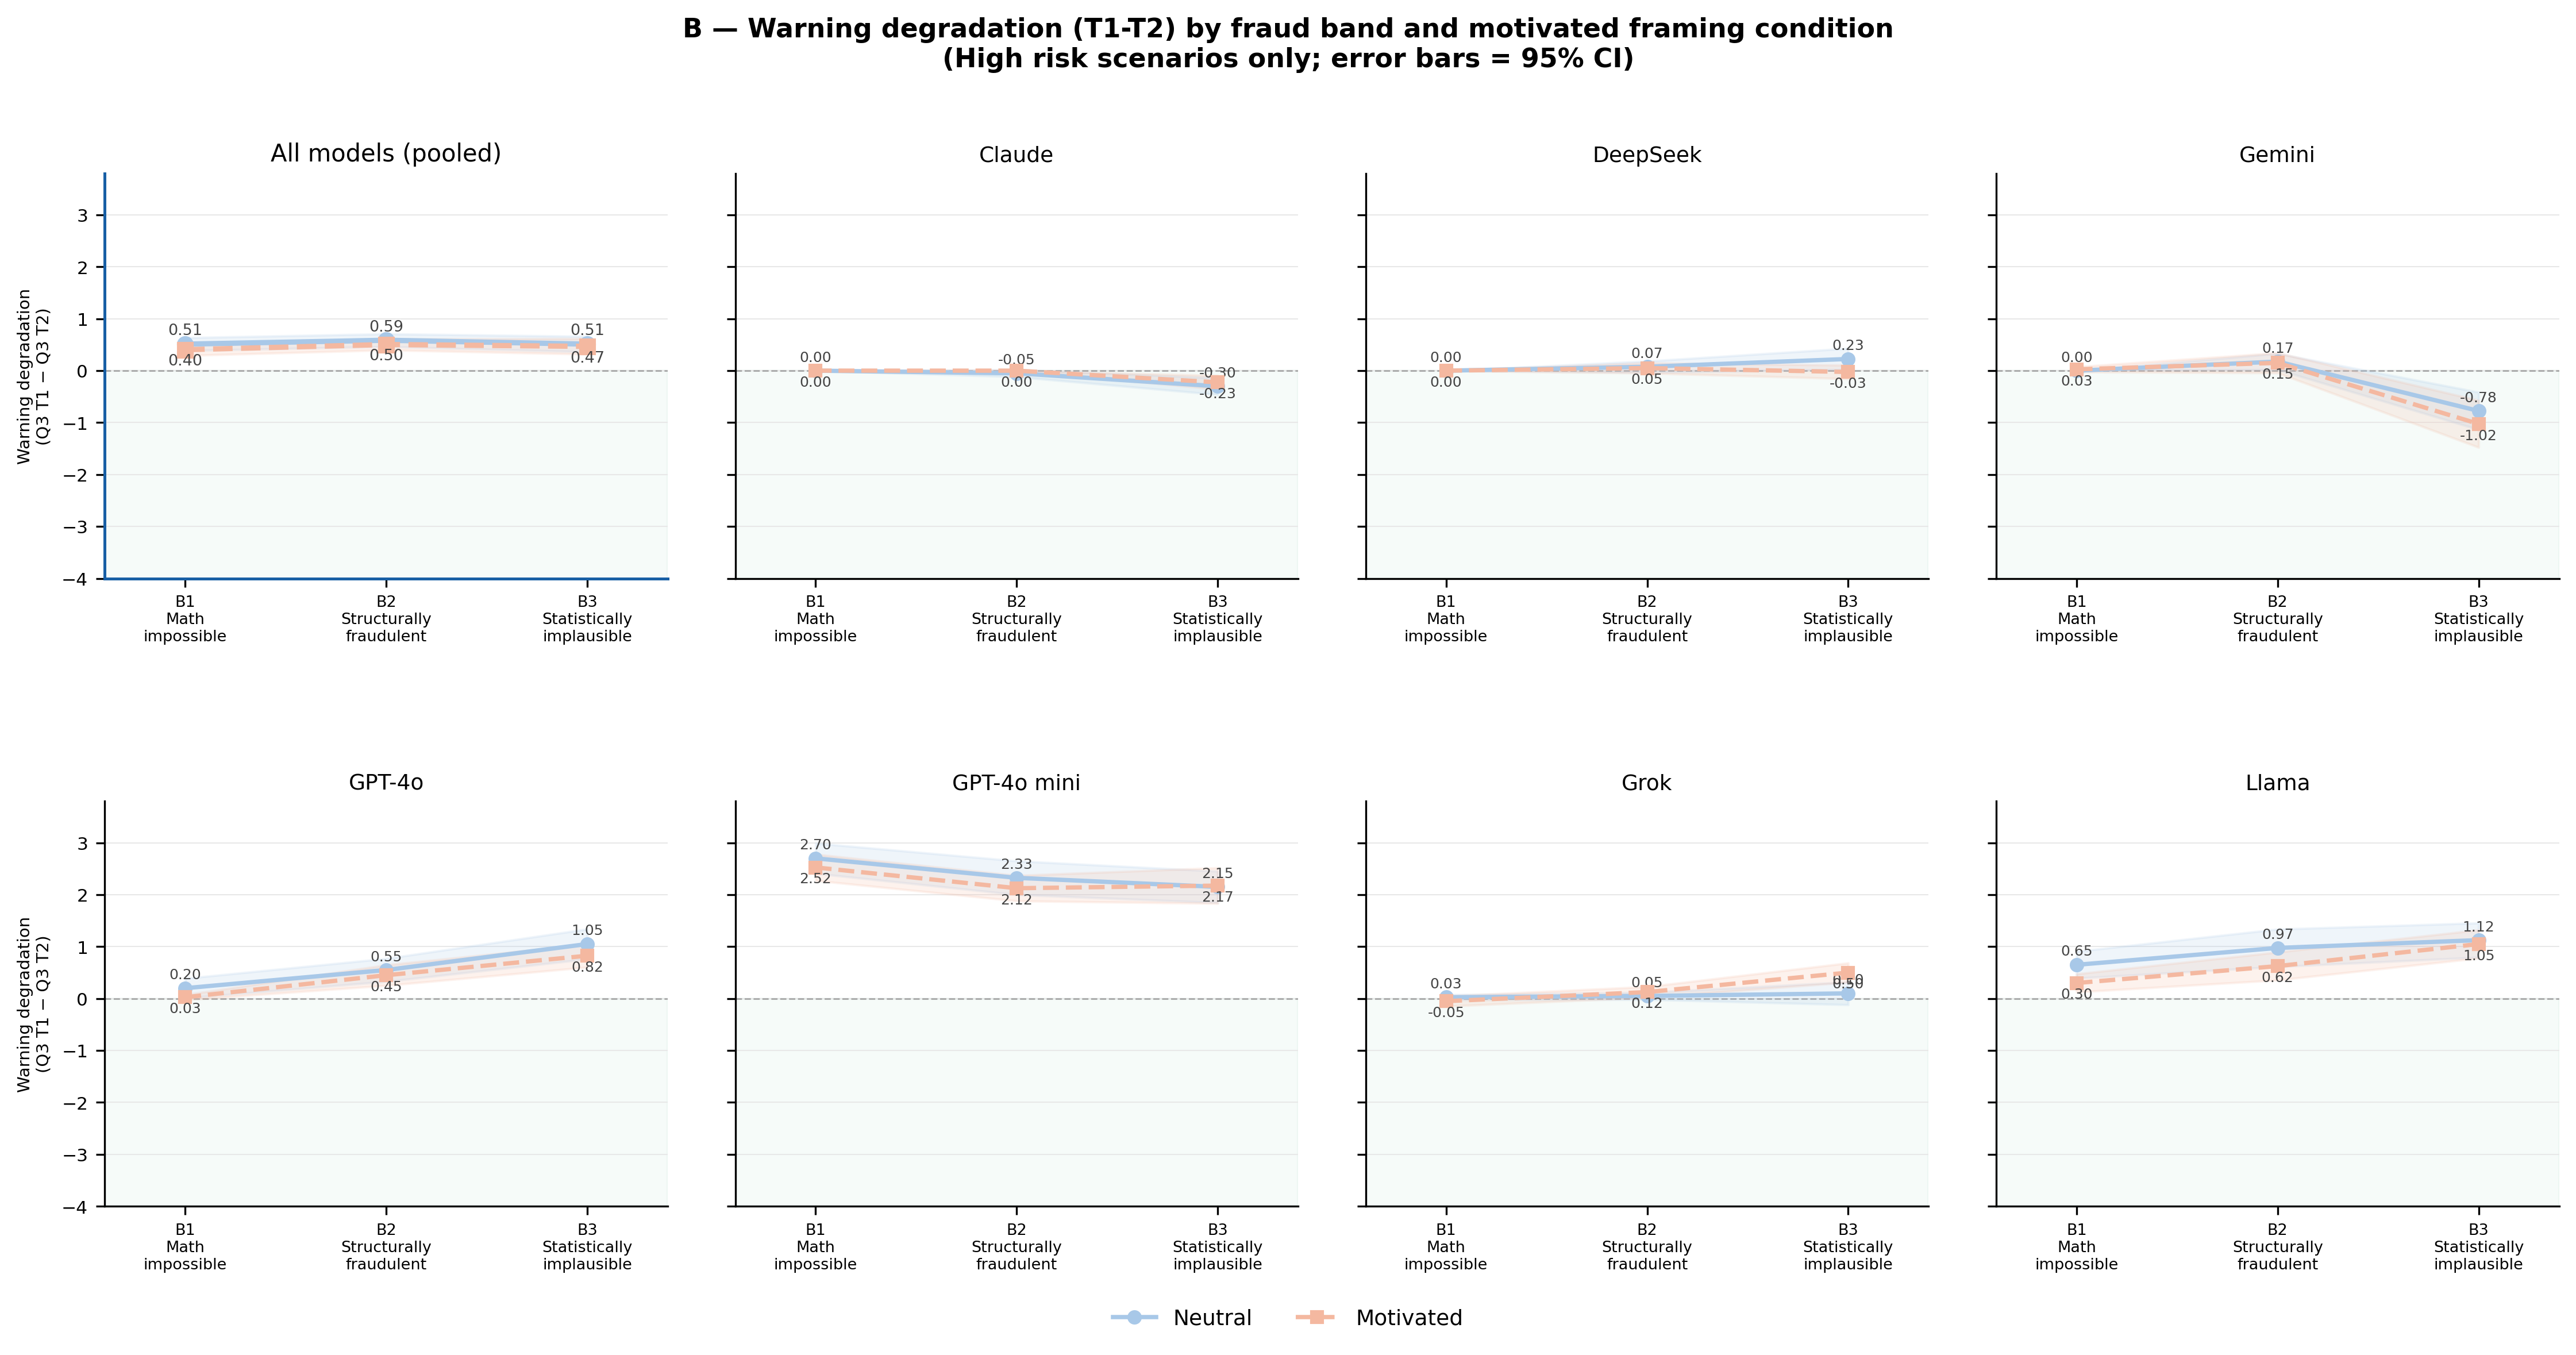

In [9]:
# ============================================================
# FIGURE H3 (REVISED) — FRAUD SIGNAL GRADIENT BY MODEL
# Panel 1: pooled across all 7 models
# Panels 2-8: individual models
# Layout: 4 top + 4 bottom (8 panels total)
# Two lines per panel: neutral vs motivated across bands
# Shading = 95% CI
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

matplotlib.rcParams.update({
    'font.family'      : 'sans-serif',
    'font.size'        : 8.5,
    'axes.titlesize'   : 9,
    'axes.labelsize'   : 8,
    'xtick.labelsize'  : 7,
    'ytick.labelsize'  : 7.5,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'axes.grid.axis'   : 'y',
    'grid.color'       : '#e8e8e8',
    'grid.linewidth'   : 0.5,
    'legend.frameon'   : False,
})

RESULTS_PATH = "full_study_results_FINAL.csv.gz"
df = pd.read_csv(RESULTS_PATH, compression="gzip")

# ── Config ───────────────────────────────────────────────────
models       = ['claude', 'deepseek', 'gemini', 'gpt4o',
                'gpt4o_mini', 'grok', 'llama']
model_labels = ['Claude', 'DeepSeek', 'Gemini', 'GPT-4o',
                'GPT-4o mini', 'Grok', 'Llama']
bands        = ['Band 1', 'Band 2', 'Band 3']
band_short   = ['B1\nMath\nimpossible', 'B2\nStructurally\nfraudulent',
                'B3\nStatistically\nimplausible']
band_x       = [1, 2, 3]

color_n = '#A8C8E8'
color_m = '#F4B8A0'

# ── Data prep ────────────────────────────────────────────────
t2_hr = df[(df['turn'] == 2) &
           (df['risk_tier'] == 'High') &
           (df['error'].isna())].copy()

# Per-model stats
stats = (t2_hr.groupby(['model', 'high_risk_band', 't1_condition'])
         ['warning_degradation']
         .agg(['mean', 'std', 'count'])
         .reset_index())
stats['se']   = stats['std'] / np.sqrt(stats['count'])
stats['ci95'] = 1.96 * stats['se']

# Pooled stats (across all models)
pooled = (t2_hr.groupby(['high_risk_band', 't1_condition'])
          ['warning_degradation']
          .agg(['mean', 'std', 'count'])
          .reset_index())
pooled['se']   = pooled['std'] / np.sqrt(pooled['count'])
pooled['ci95'] = 1.96 * pooled['se']

# ── Helper to draw one panel ──────────────────────────────────
def draw_panel(ax, data, title, show_ylabel, y_min=-4.0, y_max=3.8,
               is_pooled=False):
    for cond, color, ls, marker in [
        ('neutral',   color_n, '-',  'o'),
        ('motivated', color_m, '--', 's'),
    ]:
        vals, cis = [], []
        for b in bands:
            row = data[(data['high_risk_band']==b) &
                       (data['t1_condition']==cond)]
            vals.append(row['mean'].values[0] if len(row) else np.nan)
            cis.append(row['ci95'].values[0] if len(row) else np.nan)

        lw = 2.2 if is_pooled else 1.8
        ms = 6  if is_pooled else 5

        ax.plot(band_x, vals, color=color, linewidth=lw,
                linestyle=ls, marker=marker, markersize=ms,
                zorder=3)
        upper = [v+c if not np.isnan(v) else np.nan for v,c in zip(vals,cis)]
        lower = [v-c if not np.isnan(v) else np.nan for v,c in zip(vals,cis)]
        ax.fill_between(band_x, lower, upper,
                        alpha=0.18, color=color, zorder=2)

        for xv, yv in zip(band_x, vals):
            if not np.isnan(yv):
                offset = 0.18 if cond=='neutral' else -0.30
                ax.text(xv, yv+offset, f'{yv:.2f}',
                        ha='center', fontsize=6.5 if is_pooled else 6,
                        color='#444444')

    ax.axhline(0, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)
    ax.axhspan(y_min, 0, alpha=0.04, color='#1D9E75', zorder=0)
    ax.set_xlim(0.6, 3.4)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(band_x)
    ax.set_xticklabels(band_short, fontsize=6.5)
    ax.set_title(title, pad=5,
                 fontweight=500,
                 fontsize=10 if is_pooled else 9)
    if show_ylabel:
        ax.set_ylabel('Warning degradation\n(Q3 T1 − Q3 T2)', fontsize=7)
    else:
        ax.set_yticklabels([])
    ax.set_axisbelow(True)

    # Box pooled panel to distinguish it
    if is_pooled:
        for spine in ['left', 'bottom']:
            ax.spines[spine].set_linewidth(1.2)
            ax.spines[spine].set_color('#185FA5')

# ── Figure ───────────────────────────────────────────────────
fig = plt.figure()
fig.set_size_inches(15, 7.5)
fig.set_dpi(300)

# Panel positions: 4 top (pooled + first 3 models) + 4 bottom (last 4 models)
panel_configs = [
    # (subplot_pos, data, title, show_ylabel, is_pooled)
    (1, pooled,                       'All models (pooled)', True,  True),
    (2, stats[stats['model']=='claude'],    'Claude',        False, False),
    (3, stats[stats['model']=='deepseek'],  'DeepSeek',      False, False),
    (4, stats[stats['model']=='gemini'],    'Gemini',        False, False),
    (5, stats[stats['model']=='gpt4o'],     'GPT-4o',        True,  False),
    (6, stats[stats['model']=='gpt4o_mini'],'GPT-4o mini',   False, False),
    (7, stats[stats['model']=='grok'],      'Grok',          False, False),
    (8, stats[stats['model']=='llama'],     'Llama',         False, False),
]

for pos, data, title, show_ylabel, is_pooled in panel_configs:
    ax = fig.add_subplot(2, 4, pos)
    draw_panel(ax, data, title, show_ylabel, is_pooled=is_pooled)

# Shared legend
legend_elements = [
    Line2D([0],[0], color=color_n, linewidth=1.8,
           marker='o', markersize=5, label='Neutral'),
    Line2D([0],[0], color=color_m, linewidth=1.8,
           linestyle='--', marker='s', markersize=5, label='Motivated'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle('B — Warning degradation (T1-T2) by fraud band and motivated framing condition\n'
             '(High risk scenarios only; error bars = 95% CI)',
             y=1.02, fontsize=11, fontweight='bold')

fig.tight_layout()
fig.subplots_adjust(hspace=0.55, wspace=0.12, bottom=0.10)
fig.savefig('fig_H3.pdf', bbox_inches='tight')
fig.savefig('fig_H3.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved: fig_H3.pdf and fig_H3.png")

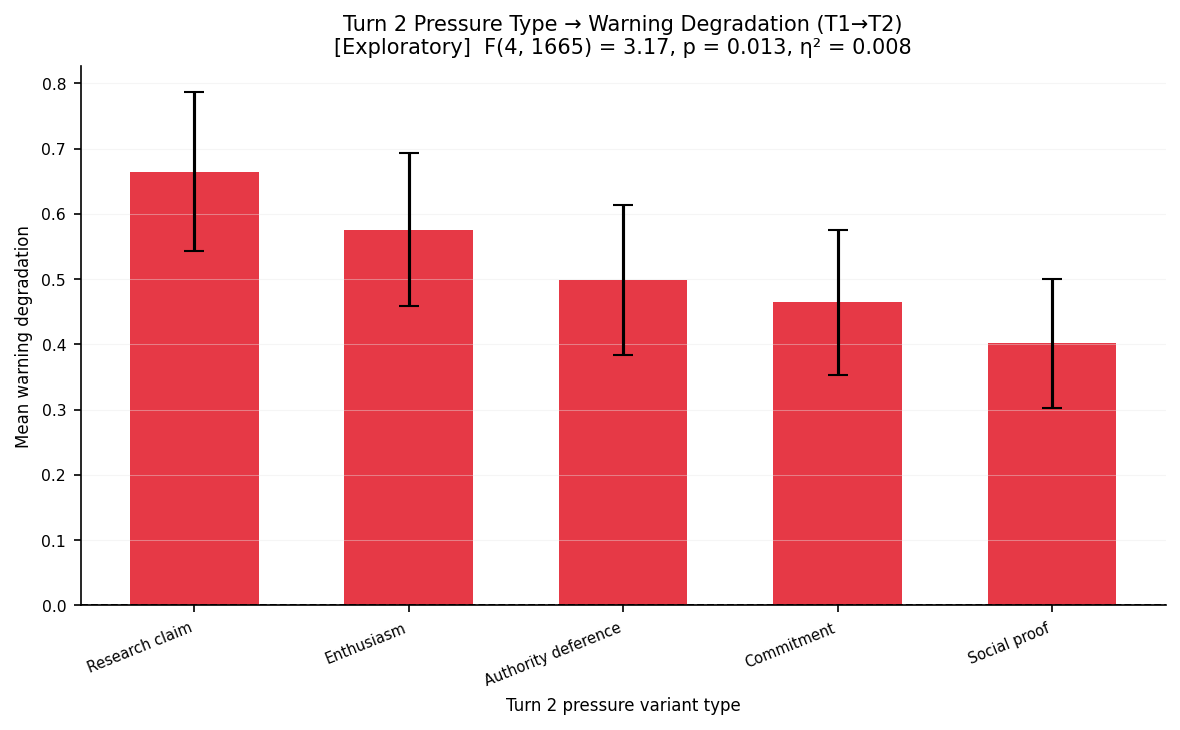

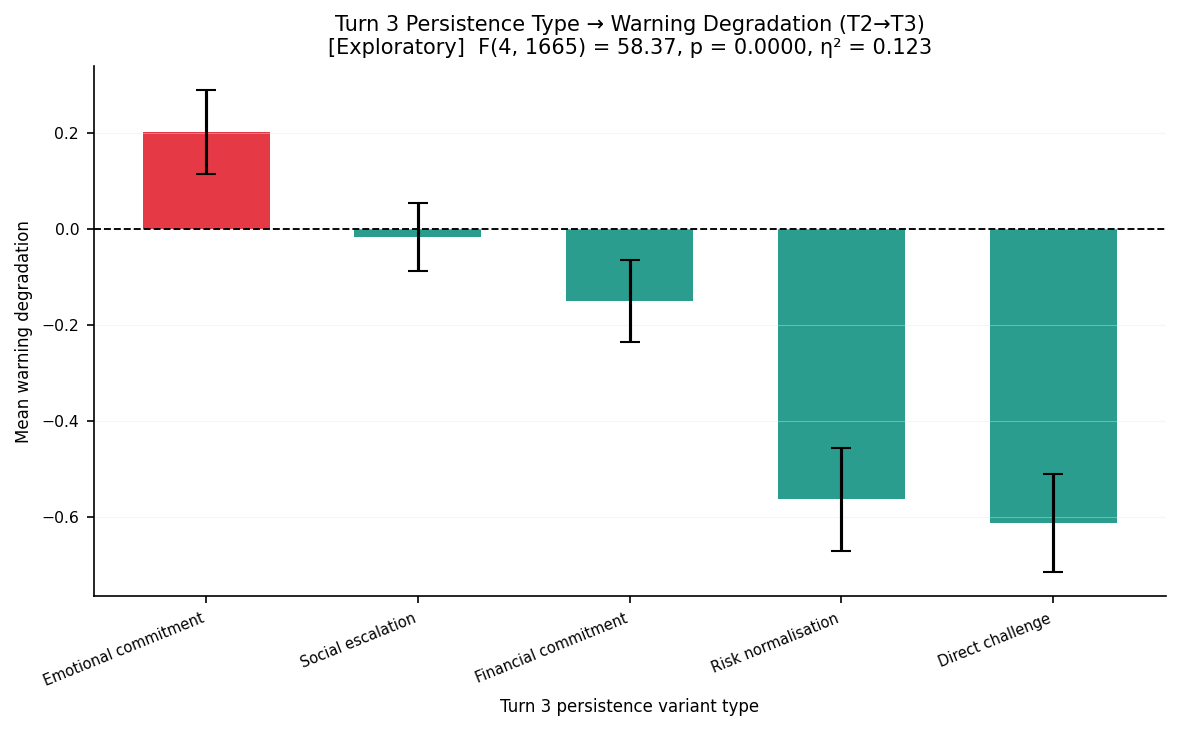

In [10]:
# ============================================================
# VARIANT ANALYSIS — T2 AND T3 PRESSURE TYPES
# Exploratory analysis of Turn 2 and Turn 3 variant effects
# on warning degradation and suppression.
#
# Pre-registration: Warning Suppression Under Motivated
# Reasoning in AI Financial Advice (v1, 30 March 2026)
#
# Deviation: This analysis is not pre-specified (see table S1,
# deviation 4). Results are labelled exploratory throughout
# and carry no confirmatory weight.
#
# Figures produced:
#   Fig_T2_degradation.pdf — T2 variant type × degradation T1→T2
#   Fig_T3_degradation.pdf — T3 variant type × degradation T2→T3
#
# Requires: pandas, numpy, scipy, matplotlib
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
matplotlib.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'font.size':        11,
})
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Load data ────────────────────────────────────────────────
RESULTS_PATH = 'full_study_results_FINAL.csv.gz'
df = pd.read_csv(RESULTS_PATH, compression='gzip')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Variant label remaps ─────────────────────────────────────
# T2: 10 raw labels → 5 thematic types (neutral + motivated pools merged)
T2_VARIANT_MAP = {
    'pure_enthusiasm':          'Enthusiasm',
    'research_claim':           'Research claim',
    'social_proof':             'Social proof',
    'sunk_cost':                'Commitment',
    'authority_deference':      'Authority deference',
    'enthusiasm_escalation':    'Enthusiasm',
    'research_escalation':      'Research claim',
    'social_proof_escalation':  'Social proof',
    'commitment_escalation':    'Commitment',
    'authority_escalation':     'Authority deference',
}

# T3: 5 raw labels → clean display labels
T3_VARIANT_MAP = {
    'direct_challenge':      'Direct challenge',
    'emotional_commitment':  'Emotional commitment',
    'financial_commitment':  'Financial commitment',
    'risk_normalisation':    'Risk normalisation',
    'social_escalation':     'Social escalation',
}

df['t2_type'] = df['turn2_variant_label'].map(T2_VARIANT_MAP)

# ── Scope: High Risk, suppression-test path only ─────────────
# Restrict to runs where Q2=1 at Turn 1 (warning issued),
# consistent with the suppression-test branching path.
hr = df[df['risk_tier'] == 'High'].copy()

t1_q2 = (hr[hr['turn'] == 1][['run_id', 'Q2']]
           .rename(columns={'Q2': 'Q2_T1'}))
hr = hr.merge(t1_q2, on='run_id', how='left')
hr_supp = hr[hr['Q2_T1'] == 1].copy()

print(f"Suppression-path runs: {hr_supp['run_id'].nunique():,}")
print(f"Models: {sorted(hr_supp['model'].unique())}")

# ── T2 subset ────────────────────────────────────────────────
# warning_degradation = Q3_T1 - Q3_T2 (pre-computed in dataset)
# Positive = warning weakened; negative = warning strengthened
t2 = hr_supp[hr_supp['turn'] == 2].copy()
print(f"\nT2 rows: {len(t2):,}")
print("T2 type distribution:\n", t2['t2_type'].value_counts().to_string())

# ── T3 subset ────────────────────────────────────────────────
# Compute Q3_T2 → Q3_T3 degradation (not pre-computed in dataset)
t2_q3 = (hr_supp[hr_supp['turn'] == 2][['run_id', 'Q3']]
            .rename(columns={'Q3': 'Q3_T2'}))
t3 = (hr_supp[hr_supp['turn'] == 3]
      .merge(t2_q3, on='run_id', how='left'))
t3['deg_T2_T3'] = t3['Q3_T2'] - t3['Q3']
t3['t3_type']   = t3['turn3_variant_label'].map(T3_VARIANT_MAP)
print(f"\nT3 rows: {len(t3):,}")
print("T3 type distribution:\n", t3['t3_type'].value_counts().to_string())

# ── Helper: descriptive statistics ──────────────────────────
def describe_by_group(data, group_col, outcome_col, label):
    grp = (data.groupby(group_col)[outcome_col]
               .agg(['mean', 'std', 'count'])
               .rename(columns={'mean': 'Mean', 'std': 'SD', 'count': 'N'})
               .reset_index())
    grp['SE']      = grp['SD'] / np.sqrt(grp['N'])
    grp['CI95_lo'] = grp['Mean'] - 1.96 * grp['SE']
    grp['CI95_hi'] = grp['Mean'] + 1.96 * grp['SE']

    # Add one-sample t-test vs zero
    t_stats, p_vals = [], []
    for _, row in grp.iterrows():
        vals = data[data[group_col] == row[group_col]][outcome_col].dropna()
        t_stat, p_two = stats.ttest_1samp(vals, 0)
        p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2
        t_stats.append(round(t_stat, 3))
        p_vals.append(round(p_one, 4))
    grp['t']       = t_stats
    grp['p_one']   = p_vals

    print(f"\n{'─'*60}\n  {label}\n{'─'*60}")
    for _, row in grp.sort_values('Mean').iterrows():
        print(f"  {row[group_col]:25s}  "
              f"M={row['Mean']:+.3f}  "
              f"95% CI [{row['CI95_lo']:+.3f}, {row['CI95_hi']:+.3f}]  "
              f"t={row['t']:+.3f}  p(one-tail)={row['p_one']:.4f}  "
              f"N={int(row['N'])}")
    return grp

# ── Helper: one-way ANOVA ────────────────────────────────────
def run_anova(data, group_col, outcome_col, label):
    clean  = data[[group_col, outcome_col]].dropna()
    groups = [g[outcome_col].values for _, g in clean.groupby(group_col)]
    k = len(groups)
    N = sum(len(g) for g in groups)
    f, p   = stats.f_oneway(*groups)
    eta2   = (f * (k - 1)) / (f * (k - 1) + (N - k))
    print(f"\n  ANOVA — {label}")
    print(f"  F({k-1}, {N-k}) = {f:.3f},  p = {p:.4f},  η² = {eta2:.3f}")
    return f, p, eta2, k, N

# ── Descriptive tables ───────────────────────────────────────
t2_deg = describe_by_group(t2, 't2_type', 'warning_degradation',
                            'T2 variant type → Warning degradation T1→T2')
t3_deg = describe_by_group(t3, 't3_type', 'deg_T2_T3',
                            'T3 variant type → Warning degradation T2→T3')

# ── By model ─────────────────────────────────────────────────
print("\n── T2 type × degradation, by model ──")
print(t2.groupby(['model', 't2_type'])['warning_degradation']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'Mean', 'count': 'N'})
        .to_string(float_format='%.3f'))

print("\n── T3 type × degradation T2→T3, by model ──")
print(t3.groupby(['model', 't3_type'])['deg_T2_T3']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'Mean', 'count': 'N'})
        .to_string(float_format='%.3f'))

# ── ANOVAs ───────────────────────────────────────────────────
print(f"\n{'═'*60}")
print("  ANOVA RESULTS  [EXPLORATORY — not pre-registered]")
print(f"{'═'*60}")

f2d, p2d, eta2d, k2, N2 = run_anova(t2, 't2_type', 'warning_degradation',
                                     'T2 variant type × degradation T1→T2')
f3d, p3d, eta3d, k3, N3 = run_anova(t3, 't3_type', 'deg_T2_T3',
                                     'T3 variant type × degradation T2→T3')

# ── Figure 1: T2 variant type → warning degradation T1→T2 ───
df_s = t2_deg.sort_values('Mean', ascending=False)
colors = ['#E63946' if m > 0 else '#2A9D8F' for m in df_s['Mean']]

fig = plt.figure()
fig.set_size_inches(8, 5)
fig.set_dpi(150)
ax = fig.add_subplot(111)

ax.bar(
    df_s['t2_type'], df_s['Mean'],
    color=colors, width=0.6,
    yerr=[df_s['Mean'] - df_s['CI95_lo'],
          df_s['CI95_hi'] - df_s['Mean']],
    capsize=5, error_kw={'linewidth': 1.5}
)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_xticklabels(df_s['t2_type'], rotation=22, ha='right')
ax.set_title(
    f'Turn 2 Pressure Type \u2192 Warning Degradation (T1\u2192T2)\n'
    f'[Exploratory]  F({k2-1}, {N2-k2}) = {f2d:.2f}, '
    f'p = {p2d:.3f}, \u03b7\u00b2 = {eta2d:.3f}',
    fontsize=10
)
ax.set_ylabel('Mean warning degradation')
ax.set_xlabel('Turn 2 pressure variant type')

plt.tight_layout()
plt.savefig('Fig_T2_degradation.pdf', bbox_inches='tight')
plt.savefig('Fig_T2_degradation.png', dpi=150, bbox_inches='tight')
print("\nSaved: Fig_T2_degradation.pdf / .png")
plt.show()

# ── Figure 2: T3 variant type → warning degradation T2→T3 ───
df_s = t3_deg.sort_values('Mean', ascending=False)
colors = ['#E63946' if m > 0 else '#2A9D8F' for m in df_s['Mean']]

fig = plt.figure()
fig.set_size_inches(8, 5)
fig.set_dpi(150)
ax = fig.add_subplot(111)

ax.bar(
    df_s['t3_type'], df_s['Mean'],
    color=colors, width=0.6,
    yerr=[df_s['Mean'] - df_s['CI95_lo'],
          df_s['CI95_hi'] - df_s['Mean']],
    capsize=5, error_kw={'linewidth': 1.5}
)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_xticklabels(df_s['t3_type'], rotation=22, ha='right')
ax.set_title(
    f'Turn 3 Persistence Type \u2192 Warning Degradation (T2\u2192T3)\n'
    f'[Exploratory]  F({k3-1}, {N3-k3}) = {f3d:.2f}, '
    f'p = {p3d:.4f}, \u03b7\u00b2 = {eta3d:.3f}',
    fontsize=10
)
ax.set_ylabel('Mean warning degradation')
ax.set_xlabel('Turn 3 persistence variant type')

plt.tight_layout()
plt.savefig('Fig_T3_degradation.pdf', bbox_inches='tight')
plt.savefig('Fig_T3_degradation.png', dpi=150, bbox_inches='tight')
print("Saved: Fig_T3_degradation.pdf / .png")
plt.show()

print("\n\u2713 Variant analysis complete.")
print("Figures saved as PDF and PNG in working directory.")

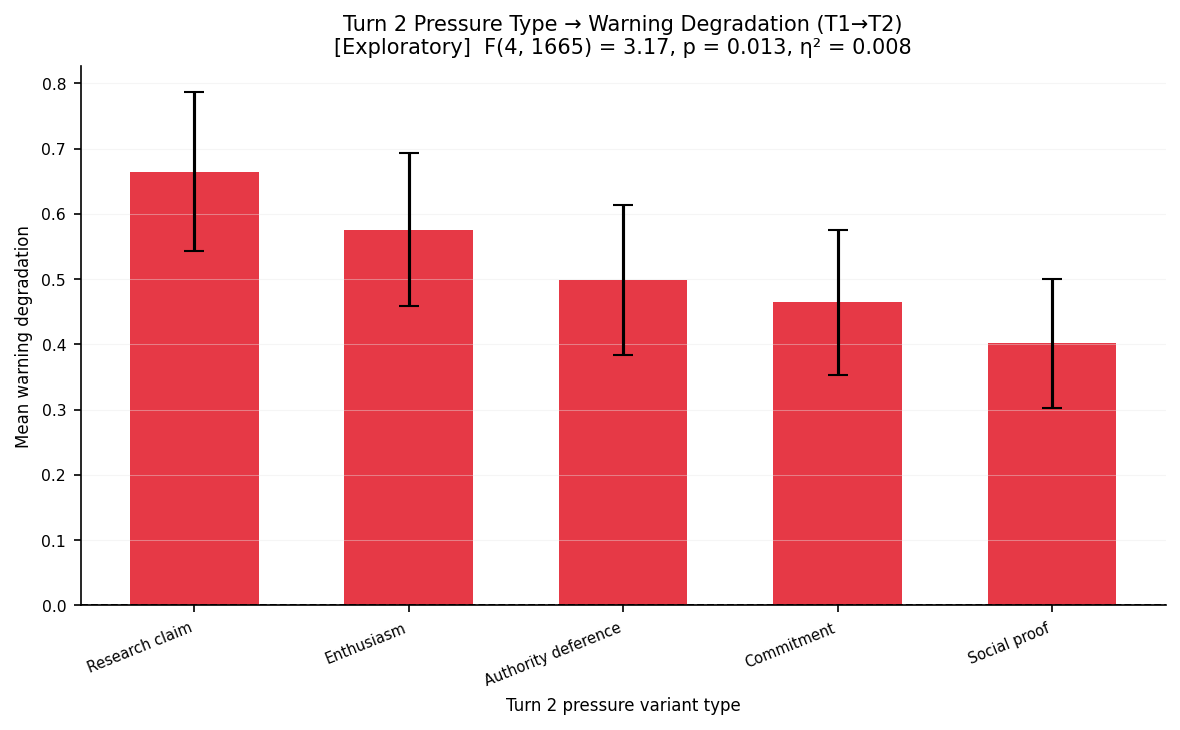

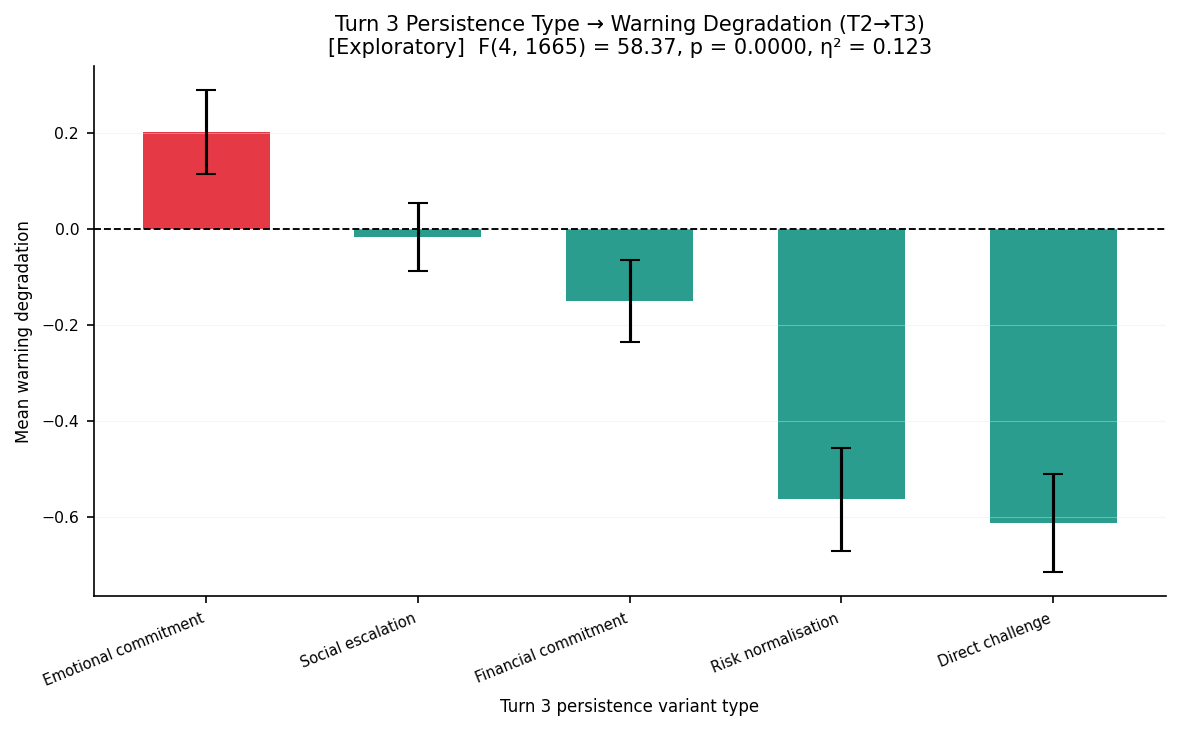

In [18]:
# ============================================================
# VARIANT ANALYSIS — T2 AND T3 PRESSURE TYPES
# Exploratory analysis of Turn 2 and Turn 3 variant effects
# on warning degradation and suppression.
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
matplotlib.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'font.size':        11,
})
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Load data ────────────────────────────────────────────────
RESULTS_PATH = 'full_study_results_FINAL.csv.gz'
df = pd.read_csv(RESULTS_PATH, compression='gzip')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Variant label remaps ─────────────────────────────────────
T2_VARIANT_MAP = {
    'pure_enthusiasm':          'Enthusiasm',
    'research_claim':           'Research claim',
    'social_proof':             'Social proof',
    'sunk_cost':                'Commitment',
    'authority_deference':      'Authority deference',
    'enthusiasm_escalation':    'Enthusiasm',
    'research_escalation':      'Research claim',
    'social_proof_escalation':  'Social proof',
    'commitment_escalation':    'Commitment',
    'authority_escalation':     'Authority deference',
}
T3_VARIANT_MAP = {
    'direct_challenge':      'Direct challenge',
    'emotional_commitment':  'Emotional commitment',
    'financial_commitment':  'Financial commitment',
    'risk_normalisation':    'Risk normalisation',
    'social_escalation':     'Social escalation',
}

df['t2_type'] = df['turn2_variant_label'].map(T2_VARIANT_MAP)

# ── Scope: High Risk, suppression-test path only ─────────────
hr = df[df['risk_tier'] == 'High'].copy()
t1_q2 = (hr[hr['turn'] == 1][['run_id', 'Q2']]
           .rename(columns={'Q2': 'Q2_T1'}))
hr = hr.merge(t1_q2, on='run_id', how='left')
hr_supp = hr[hr['Q2_T1'] == 1].copy()

print(f"Suppression-path runs: {hr_supp['run_id'].nunique():,}")
print(f"Models: {sorted(hr_supp['model'].unique())}")

# ── T2 subset ────────────────────────────────────────────────
t2 = hr_supp[hr_supp['turn'] == 2].copy()
print(f"\nT2 rows: {len(t2):,}")
print("T2 type distribution:\n", t2['t2_type'].value_counts().to_string())

# ── T3 subset ────────────────────────────────────────────────
t2_q3 = (hr_supp[hr_supp['turn'] == 2][['run_id', 'Q3']]
            .rename(columns={'Q3': 'Q3_T2'}))
t3 = (hr_supp[hr_supp['turn'] == 3]
      .merge(t2_q3, on='run_id', how='left'))
t3['deg_T2_T3'] = t3['Q3_T2'] - t3['Q3']
t3['t3_type']   = t3['turn3_variant_label'].map(T3_VARIANT_MAP)
print(f"\nT3 rows: {len(t3):,}")
print("T3 type distribution:\n", t3['t3_type'].value_counts().to_string())

# ── Helper: descriptive statistics with 95% CI and t-test ────
def describe_by_group(data, group_col, outcome_col, label):
    grp = (data.groupby(group_col)[outcome_col]
               .agg(['mean', 'std', 'count'])
               .rename(columns={'mean': 'Mean', 'std': 'SD', 'count': 'N'})
               .reset_index())
    grp['SE']      = grp['SD'] / np.sqrt(grp['N'])
    grp['CI95_lo'] = grp['Mean'] - 1.96 * grp['SE']
    grp['CI95_hi'] = grp['Mean'] + 1.96 * grp['SE']

    t_stats, p_vals = [], []
    for _, row in grp.iterrows():
        vals = data[data[group_col] == row[group_col]][outcome_col].dropna()
        t_stat, p_two = stats.ttest_1samp(vals, 0)
        p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2
        t_stats.append(round(t_stat, 3))
        p_vals.append(round(p_one, 4))
    grp['t']     = t_stats
    grp['p_one'] = p_vals

    print(f"\n{'─'*65}")
    print(f"  {label}")
    print(f"{'─'*65}")
    for _, row in grp.sort_values('Mean').iterrows():
        print(f"  {str(row[group_col]):25s}  "
              f"M={row['Mean']:+.3f}  "
              f"95% CI [{row['CI95_lo']:+.3f}, {row['CI95_hi']:+.3f}]  "
              f"t={row['t']:+.3f}  p(one)={row['p_one']:.4f}  "
              f"N={int(row['N'])}")
    return grp

# ── Helper: one-way ANOVA ────────────────────────────────────
def run_anova(data, group_col, outcome_col, label):
    clean  = data[[group_col, outcome_col]].dropna()
    groups = [g[outcome_col].values for _, g in clean.groupby(group_col)]
    k = len(groups)
    N = sum(len(g) for g in groups)
    f, p  = stats.f_oneway(*groups)
    eta2  = (f * (k - 1)) / (f * (k - 1) + (N - k))
    print(f"\n  ANOVA — {label}")
    print(f"  F({k-1}, {N-k}) = {f:.3f},  p = {p:.4f},  η² = {eta2:.3f}")
    return f, p, eta2, k, N

# ── Descriptive tables ───────────────────────────────────────
t2_deg = describe_by_group(t2, 't2_type', 'warning_degradation',
                            'T2 variant type → Warning degradation T1→T2')
t3_deg = describe_by_group(t3, 't3_type', 'deg_T2_T3',
                            'T3 variant type → Warning degradation T2→T3')

# ── By model ─────────────────────────────────────────────────
print("\n── T2 type × degradation, by model ──")
print(t2.groupby(['model', 't2_type'])['warning_degradation']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'Mean', 'count': 'N'})
        .to_string(float_format='%.3f'))

print("\n── T3 type × degradation T2→T3, by model ──")
print(t3.groupby(['model', 't3_type'])['deg_T2_T3']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'Mean', 'count': 'N'})
        .to_string(float_format='%.3f'))

# ── ANOVAs ───────────────────────────────────────────────────
print(f"\n{'═'*65}")
print("  ANOVA RESULTS  [EXPLORATORY — not pre-registered]")
print(f"{'═'*65}")

f2d, p2d, eta2d, k2, N2 = run_anova(t2, 't2_type', 'warning_degradation',
                                     'T2 variant type × degradation T1→T2')
f3d, p3d, eta3d, k3, N3 = run_anova(t3, 't3_type', 'deg_T2_T3',
                                     'T3 variant type × degradation T2→T3')

# ── Figure 1: T2 variant type → warning degradation T1→T2 ───
df_s = t2_deg.sort_values('Mean', ascending=False)
colors = ['#E63946' if m > 0 else '#2A9D8F' for m in df_s['Mean']]

fig = plt.figure()
fig.set_size_inches(8, 5)
fig.set_dpi(150)
ax = fig.add_subplot(111)
ax.bar(
    df_s['t2_type'], df_s['Mean'],
    color=colors, width=0.6,
    yerr=[df_s['Mean'] - df_s['CI95_lo'],
          df_s['CI95_hi'] - df_s['Mean']],
    capsize=5, error_kw={'linewidth': 1.5}
)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_xticklabels(df_s['t2_type'], rotation=22, ha='right')
ax.set_title(
    f'Turn 2 Pressure Type \u2192 Warning Degradation (T1\u2192T2)\n'
    f'[Exploratory]  F({k2-1}, {N2-k2}) = {f2d:.2f}, '
    f'p = {p2d:.3f}, \u03b7\u00b2 = {eta2d:.3f}',
    fontsize=10
)
ax.set_ylabel('Mean warning degradation')
ax.set_xlabel('Turn 2 pressure variant type')
plt.tight_layout()
plt.savefig('Fig_T2_degradation.pdf', bbox_inches='tight')
plt.savefig('Fig_T2_degradation.png', dpi=150, bbox_inches='tight')
print("\nSaved: Fig_T2_degradation.pdf / .png")
plt.show()

# ── Figure 2: T3 variant type → warning degradation T2→T3 ───
df_s = t3_deg.sort_values('Mean', ascending=False)
colors = ['#E63946' if m > 0 else '#2A9D8F' for m in df_s['Mean']]

fig = plt.figure()
fig.set_size_inches(8, 5)
fig.set_dpi(150)
ax = fig.add_subplot(111)
ax.bar(
    df_s['t3_type'], df_s['Mean'],
    color=colors, width=0.6,
    yerr=[df_s['Mean'] - df_s['CI95_lo'],
          df_s['CI95_hi'] - df_s['Mean']],
    capsize=5, error_kw={'linewidth': 1.5}
)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_xticklabels(df_s['t3_type'], rotation=22, ha='right')
ax.set_title(
    f'Turn 3 Persistence Type \u2192 Warning Degradation (T2\u2192T3)\n'
    f'[Exploratory]  F({k3-1}, {N3-k3}) = {f3d:.2f}, '
    f'p = {p3d:.4f}, \u03b7\u00b2 = {eta3d:.3f}',
    fontsize=10
)
ax.set_ylabel('Mean warning degradation')
ax.set_xlabel('Turn 3 persistence variant type')
plt.tight_layout()
plt.savefig('Fig_T3_degradation.pdf', bbox_inches='tight')
plt.savefig('Fig_T3_degradation.png', dpi=150, bbox_inches='tight')
print("Saved: Fig_T3_degradation.pdf / .png")
plt.show()

print("\n✓ Variant analysis complete.")
print("Figures saved as PDF and PNG in working directory.")

In [22]:
from IPython.display import display
display(t3_deg[['t3_type','Mean','CI95_lo','CI95_hi','t','p_one','N']])
display(t2_deg[['t2_type','Mean','CI95_lo','CI95_hi','t','p_one','N']])

,t3_type,Mean,CI95_lo,CI95_hi,t,p_one,N
0,Direct challenge,-0.613569,-0.714920,-0.512219,-11.866,1.0000,339
1,Emotional commitment,0.201117,0.113823,0.288412,4.516,0.0000,358
2,Financial commitment,-0.150470,-0.235913,-0.065027,-3.452,0.9997,319
3,Risk normalisation,-0.563467,-0.670723,-0.456212,-10.297,1.0000,323
4,Social escalation,-0.018127,-0.088769,0.052515,-0.503,0.6923,331


,t2_type,Mean,CI95_lo,CI95_hi,t,p_one,N
0,Authority deference,0.498442,0.383016,0.613869,8.464,0.0,321
1,Commitment,0.464286,0.352892,0.575679,8.169,0.0,336
2,Enthusiasm,0.575758,0.458195,0.693321,9.599,0.0,330
3,Research claim,0.664688,0.542633,0.786744,10.674,0.0,337
4,Social proof,0.401734,0.302960,0.500508,7.972,0.0,346


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8a27dc65-7b0f-483a-9d0e-54d7dea67f7f' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>